# Lifestyle Phenotypes and Insomnia Prediction in US Adults
**Milestone 2 Master Notebook**


Project description:

Table of contents:



## Metabolic Syndrome (MetS)

Metabolic Syndrome is a clinically defined cluster of cardiometabolic risk factors that together significantly increase the risk of type 2 diabetes, cardiovascular disease, and related conditions. Diagnosis requires **any 3 of the following 5 harmonised criteria** (IDF/AHA/NHLBI 2009 consensus):

| Criterion | Threshold |
|---|---|
| Abdominal obesity | Elevated waist circumference (population-specific cut-offs) |
| High triglycerides | ≥ 150 mg/dL |
| Low HDL cholesterol | < 40 mg/dL (men), < 50 mg/dL (women) |
| High blood pressure | ≥ 130 systolic or ≥ 85 diastolic mmHg |
| High fasting glucose | ≥ 100 mg/dL |

This panel directly informs our clustering feature set. Rather than diagnosing MetS as a binary outcome, we use the underlying continuous biomarkers as input to k-means, allowing the model to identify distinct metabolic phenotypes within the population. These phenotype labels are then introduced as engineered features in the supervised model to test whether metabolic subgroup membership improves prediction of sleep problems beyond standard covariates.

P_BIOPRO: Standard Biochemistry Profile

P_BIOPRO contains 41 serum chemistry variables across 10,409 participants — the largest sample of any lab file in the pre-pandemic release. We extract three variables as extended (Tier 2) metabolic features:

- **LBXSUA (Uric Acid):** elevated uric acid (hyperuricemia) is independently associated with insulin resistance, hypertension, and metabolic syndrome, and has been linked to poor sleep quality and obstructive sleep apnoea.
- **LBXSATSI (ALT):** primary clinical marker of non-alcoholic fatty liver disease (NAFLD), which is recognised as the hepatic manifestation of metabolic syndrome.
- **LBXSGTSI (GGT):** liver enzyme sensitive to early metabolic dysfunction and oxidative stress, independently associated with insulin resistance even without significant alcohol use.

These three markers allow the k-means model to surface a liver/inflammation-driven phenotype that the five harmonised MetS criteria alone would not separate out.

In [1]:
# Install missing Python packages before running the notebook.
# This helps fresh local, PyCharm, or Colab environments run the import cell below.
import importlib.util
import subprocess
import sys

required_packages = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "statsmodels": "statsmodels",
    "umap": "umap-learn",
    "xgboost": "xgboost",
}

missing_packages = sorted({
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
})

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required Python packages are already installed.")


All required Python packages are already installed.


## Dataset Loading & Cleaning

In [2]:
# Standard library
import os
from functools import reduce
from pathlib import Path

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import dendrogram, linkage
from umap import UMAP
from xgboost import XGBClassifier

# Scikit-learn: clustering and unsupervised learning
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.utils import resample

# Scikit-learn: preprocessing and pipelines
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
)

# Scikit-learn: model selection
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

# Scikit-learn: supervised models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Scikit-learn: evaluation metrics and displays
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

In [3]:
# Data folder configuration
# Default: run from the cloned repo, where NHANES files live under data/.
# Optional for Colab: mount Google Drive and update DATA_DIR to your Drive data folder.

DATA_DIR = Path("data")

# Optional Colab/Google Drive setup:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = Path("/content/drive/MyDrive/Milestone 2/data")

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Could not find the NHANES data folder at {DATA_DIR.resolve()}. "
        "If you are using Colab, mount Google Drive and update DATA_DIR above."
    )

category_paths = {
    "Lab": DATA_DIR / "Lab",
    "Questionnaire": DATA_DIR / "Questionnaire",
    "Demographic": DATA_DIR / "Demographic",
    "Examination": DATA_DIR / "Examination",
}

missing_folders = [name for name, path in category_paths.items() if not path.exists()]
if missing_folders:
    raise FileNotFoundError(f"Missing expected data folders: {missing_folders}")

print(f"Using data folder: {DATA_DIR.resolve()}")


Using data folder: /Users/yasthilsingh/PycharmProjects/Cardiometabolic-Phenotypes-and-Predicted-Trouble-Sleeping-in-US-Adults/data


In [4]:
# Selected NHANES files and friendly names used in this project.
lab_file_descriptions = {
    "P_GHB.xpt": "Glycohemoglobin",
    "P_GLU.xpt": "Fasting Glucose",
    "P_HDL.xpt": "HDL Cholesterol",
    "P_HSCRP.xpt": "High-Sensitivity C-Reactive Protein",
    "P_INS.xpt": "Insulin",
    "P_TCHOL.xpt": "Total Cholesterol",
    "P_TRIGLY.xpt": "Triglycerides",
    "P_BIOPRO.xpt": "Standard Biochemistry Profile",
    "P_FASTQX.xpt": "Fasting Questionnaire",
}

questionnaire_file_descriptions = {
    "P_PAQ.xpt": "Physical Activity Questionnaire",
    "P_DBQ.xpt": "Dietary Behavior Questionnaire",
    "P_DIQ.xpt": "Diabetes Questionnaire",
    "P_BPQ.xpt": "Blood Pressure and Cholesterol Questionnaire",
    "P_SMQ.xpt": "Smoking Questionnaire",
    "P_SLQ.xpt": "Sleep Disorders Questionnaire",
    "P_MCQ.xpt": "Medical Conditions Questionnaire",
    "P_ALQ.xpt": "Alcohol Use Questionnaire",
    "P_DPQ.xpt": "Depression Screener (PHQ-9)",
}

demographic_file_descriptions = {
    "P_DEMO.xpt": "Demographics",
}

examination_file_descriptions = {
    "P_BMX.xpt": "Body Measures",
    "P_BPXO.xpt": "Blood Pressure - Oscillometric Measurement",
}

# Raw NHANES names are keys; analysis-friendly names are values.
column_names = {
    # Demographics
    "SEQN": "ID",
    "RIDAGEYR": "Age",
    "RIAGENDR": "Sex",
    "SDDSRVYR": "Survey Cycle",

    # Physical activity
    "PAQ605": "Vigorous Work Activity",
    "PAQ610": "Vigorous Work Days",
    "PAD615": "Vigorous Work Minutes",
    "PAQ620": "Moderate Work Activity",
    "PAQ625": "Moderate Work Days",
    "PAD630": "Moderate Work Minutes",
    "PAQ635": "Walk or Bicycle for Transportation",
    "PAQ640": "Walk/Bicycle Days",
    "PAD645": "Walk/Bicycle Minutes",
    "PAQ650": "Vigorous Recreational Activity",
    "PAQ655": "Vigorous Recreational Days",
    "PAD660": "Vigorous Recreational Minutes",
    "PAQ665": "Moderate Recreational Activity",
    "PAQ670": "Moderate Recreational Days",
    "PAD675": "Moderate Recreational Minutes",
    "PAD680": "Sedentary Minutes",

    # Core metabolic biomarkers
    "LBXGH": "Glycohemoglobin (%)",
    "LBXGLU": "Fasting Glucose (mg/dL)",
    "LBXIN": "Insulin (µU/mL)",
    "LBDHDD": "HDL Cholesterol (mg/dL)",
    "LBXTC": "Total Cholesterol (mg/dL)",
    "LBXTR": "Triglycerides (mg/dL)",
    "LBXHSCRP": "HS C-Reactive Protein (mg/L)",

    # Extended metabolic markers
    "LBXSUA": "Uric Acid (mg/dL)",
    "LBXSATSI": "ALT (U/L)",
    "LBXSGTSI": "GGT (U/L)",

    # Body measures
    "BMXBMI": "BMI (kg/m^2)",
    "BMXWAIST": "Waist Circumference (cm)",

    # Blood pressure readings
    "BPXOSY1": "Systolic BP 1 (mmHg)",
    "BPXOSY2": "Systolic BP 2 (mmHg)",
    "BPXOSY3": "Systolic BP 3 (mmHg)",
    "BPXODI1": "Diastolic BP 1 (mmHg)",
    "BPXODI2": "Diastolic BP 2 (mmHg)",
    "BPXODI3": "Diastolic BP 3 (mmHg)",

    # Sleep
    "SLQ300": "Weekday Sleep Time",
    "SLQ310": "Weekday Wake Time",
    "SLD012": "Weekday Sleep Hours",
    "SLQ320": "Weekend Sleep Time",
    "SLQ330": "Weekend Wake Time",
    "SLD013": "Weekend Sleep Hours",
    "SLQ030": "Snoring Frequency",
    "SLQ040": "Stop Breathing During Sleep Frequency",
    "SLQ050": "Doctor Told Trouble Sleeping",
    "SLQ120": "Daytime Sleepiness Frequency",


    "WTSAFPRP": "Fasting Weight",
    "WTMECPRP": "MEC Weight",
    "SDMVPSU": "PSU",
    "SDMVSTRA": "Stratum",
}

## Step 1: Data Cleaning

In [5]:
def convert_to_df(folder_path, filename):
    """Read one NHANES XPT file into a DataFrame."""
    file_path = Path(folder_path) / filename
    return pd.read_sas(file_path, format="xport")


def load_selected_files(folder_path, file_descriptions, category_name):
    """Load the selected files for one NHANES category and print readable progress."""
    dataframes = []
    missing_files = []

    for index, (filename, friendly_name) in enumerate(file_descriptions.items(), start=1):
        file_path = Path(folder_path) / filename

        if not file_path.exists():
            missing_files.append(filename)
            continue

        df = convert_to_df(folder_path, filename)
        dataframes.append(df)
        print(f"{category_name} DataFrame {index}: {friendly_name} ({filename}) {df.shape}")

    if missing_files:
        print(f"Missing {category_name} files: {missing_files}")

    return dataframes


lab_df_list = load_selected_files(category_paths["Lab"], lab_file_descriptions, "Lab")
questionnaire_df_list = load_selected_files(
    category_paths["Questionnaire"],
    questionnaire_file_descriptions,
    "Questionnaire",
)
demographic_df_list = load_selected_files(
    category_paths["Demographic"],
    demographic_file_descriptions,
    "Demographic",
)
examination_df_list = load_selected_files(
    category_paths["Examination"],
    examination_file_descriptions,
    "Examination",
)



Lab DataFrame 1: Glycohemoglobin (P_GHB.xpt) (10409, 2)
Lab DataFrame 2: Fasting Glucose (P_GLU.xpt) (5090, 4)
Lab DataFrame 3: HDL Cholesterol (P_HDL.xpt) (12198, 3)
Lab DataFrame 4: High-Sensitivity C-Reactive Protein (P_HSCRP.xpt) (13772, 3)
Lab DataFrame 5: Insulin (P_INS.xpt) (5090, 5)
Lab DataFrame 6: Total Cholesterol (P_TCHOL.xpt) (12198, 3)
Lab DataFrame 7: Triglycerides (P_TRIGLY.xpt) (5090, 10)
Lab DataFrame 8: Standard Biochemistry Profile (P_BIOPRO.xpt) (10409, 41)
Lab DataFrame 9: Fasting Questionnaire (P_FASTQX.xpt) (13772, 19)
Questionnaire DataFrame 1: Physical Activity Questionnaire (P_PAQ.xpt) (9693, 17)
Questionnaire DataFrame 2: Dietary Behavior Questionnaire (P_DBQ.xpt) (15560, 46)
Questionnaire DataFrame 3: Diabetes Questionnaire (P_DIQ.xpt) (14986, 28)
Questionnaire DataFrame 4: Blood Pressure and Cholesterol Questionnaire (P_BPQ.xpt) (10195, 11)
Questionnaire DataFrame 5: Smoking Questionnaire (P_SMQ.xpt) (11137, 16)
Questionnaire DataFrame 6: Sleep Disorders Q

Load + Merge: Lab, Questionaire, Demographic and Examination Files

In [6]:
def merge_on_participant_id(dataframes, id_col="SEQN"):
    """Merge NHANES DataFrames on the participant identifier.
    Drops duplicate non-ID columns from later files before each outer merge.
    """
    dataframes = [df for df in dataframes if id_col in df.columns]
    print(f"DataFrames with {id_col}:", len(dataframes))

    if not dataframes:
        raise ValueError(f"No loaded DataFrames contain {id_col}, so the files cannot be merged.")

    merged_df = dataframes[0].copy()

    for df in dataframes[1:]:
        overlap_cols = merged_df.columns.intersection(df.columns).drop(id_col, errors="ignore")
        merged_df = merged_df.merge(df.drop(columns=overlap_cols), on=id_col, how="outer")

    return merged_df


all_df_list = demographic_df_list + questionnaire_df_list + lab_df_list + examination_df_list
master_df = merge_on_participant_id(all_df_list)

print("Master dataframe shape:", master_df.shape)
master_df.head()

DataFrames with SEQN: 21
Master dataframe shape: (15560, 344)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,...,BPAOCSZ,BPXOSY1,BPXODI1,BPXOSY2,BPXODI2,BPXOSY3,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3
0,109263.0,66.0,2.0,1.0,2.0,NaN,5.0,6.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109264.0,66.0,2.0,2.0,13.0,NaN,1.0,1.0,2.0,1.0,...,3.0,109.0,67.0,109.0,68.0,106.0,66.0,94.0,95.0,91.0
2,109265.0,66.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109266.0,66.0,2.0,2.0,29.0,NaN,5.0,6.0,2.0,2.0,...,4.0,99.0,56.0,99.0,55.0,99.0,52.0,68.0,66.0,66.0
4,109267.0,66.0,1.0,2.0,21.0,NaN,2.0,2.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
[c for c in master_df.columns if 'WTSAF' in c or 'WTMEC' in c]

['WTMECPRP', 'WTSAFPRP']

In [8]:
def create_analysis_dataframe(master_df, column_names):
    """Select project columns and apply friendly names.
    Cleans core demographic types while preserving the full master_df upstream.
    """
    analysis_cols = [col for col in column_names if col in master_df.columns]
    missing_cols = [col for col in column_names if col not in master_df.columns]

    analysis_df = master_df.loc[:, analysis_cols].copy()
    analysis_df.rename(columns=column_names, inplace=True)

    if "Sex" in analysis_df.columns:
        analysis_df["Sex"] = analysis_df["Sex"].map({1.0: "Male", 2.0: "Female"})

    for col in ["ID", "Age"]:
        if col in analysis_df.columns:
            analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce").round().astype("Int64")

    analysis_df.reset_index(drop=True, inplace=True)
    return analysis_df, analysis_cols, missing_cols


analysis_df, analysis_cols, missing_cols = create_analysis_dataframe(master_df, column_names)

print(f"Kept {len(analysis_cols)} columns out of {master_df.shape[1]} total columns.")

if missing_cols:
    print("Columns not found in master_df:")
    print(missing_cols)

analysis_df.head()




Kept 52 columns out of 344 total columns.


,ID,Age,Sex,Survey Cycle,Vigorous Work Activity,Vigorous Work Days,Vigorous Work Minutes,Moderate Work Activity,Moderate Work Days,Moderate Work Minutes,...,Weekend Wake Time,Weekend Sleep Hours,Snoring Frequency,Stop Breathing During Sleep Frequency,Doctor Told Trouble Sleeping,Daytime Sleepiness Frequency,Fasting Weight,MEC Weight,PSU,Stratum
0,109263,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.951816e+03,3.0,156.0
1,109264,13,Female,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27533.174559,1.227116e+04,1.0,155.0
2,109265,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.665876e+04,1.0,157.0
3,109266,29,Female,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'07:00',8.0,1.000000e+00,5.397605e-79,2.0,5.397605e-79,NaN,8.154968e+03,2.0,168.0
4,109267,21,Female,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'11:00',8.0,5.397605e-79,5.397605e-79,2.0,2.000000e+00,NaN,5.397605e-79,1.0,156.0


In [9]:
# Clean survey weight columns.
# Some SAS/XPT zero values may be read by pandas as extremely tiny positive values.
# Treat anything effectively zero as true zero.

survey_weight_cols = ["Fasting Weight", "MEC Weight"]

for col in survey_weight_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")
        analysis_df.loc[analysis_df[col] < 1e-12, col] = 0.0

In [10]:
# Step 6: Cap highly skewed numeric analysis columns at the 99th percentile.

def cap_columns_at_quantile(df, columns, quantile=0.99):
    """Cap selected columns at a chosen upper quantile.
    Returns the capped DataFrame and the list of columns that were found.
    """
    existing_cols = [col for col in columns if col in df.columns]

    for col in existing_cols:
        upper_limit = df[col].quantile(quantile)
        df[col] = df[col].clip(upper=upper_limit)

    return df, existing_cols


columns_to_cap = [
    "Fasting Glucose (mg/dL)",
    "Glycohemoglobin (%)",
    "HDL Cholesterol (mg/dL)",
    "Total Cholesterol (mg/dL)",
    "Triglycerides (mg/dL)",
    "Insulin (µU/mL)",
    "HS C-Reactive Protein (mg/L)",
    "Uric Acid (mg/dL)",
    "ALT (U/L)",
    "GGT (U/L)",
    "BMI (kg/m^2)",
    "Waist Circumference (cm)",
    "Sedentary Minutes",
    "Moderate_Weekly_Minutes",
    "Vigorous_Weekly_Minutes",
    "Total_Weekly_Mins",
    "Total_MVPA_Equivalent_Mins",
]

analysis_df, capped_cols = cap_columns_at_quantile(analysis_df, columns_to_cap)

print("Capped columns:")
print(capped_cols)

Capped columns:
['Fasting Glucose (mg/dL)', 'Glycohemoglobin (%)', 'HDL Cholesterol (mg/dL)', 'Total Cholesterol (mg/dL)', 'Triglycerides (mg/dL)', 'Insulin (µU/mL)', 'HS C-Reactive Protein (mg/L)', 'Uric Acid (mg/dL)', 'ALT (U/L)', 'GGT (U/L)', 'BMI (kg/m^2)', 'Waist Circumference (cm)', 'Sedentary Minutes']


## Feature Engineering for Modeling

The next cells create a clean modeling table from the cleaned `analysis_df`.

In [11]:
def normalize_tiny_zero_artifacts(df, threshold=1e-12):
    """Convert tiny SAS XPORT zero artifacts into true zeros.
    Leaves nonnumeric columns unchanged and returns a cleaned copy.
    """
    cleaned_df = df.copy()
    numeric_cols = cleaned_df.select_dtypes(include="number").columns
    cleaned_df[numeric_cols] = cleaned_df[numeric_cols].mask(cleaned_df[numeric_cols].abs() < threshold, 0)
    return cleaned_df


def make_binary_response(series, yes_value=1, no_value=2):
    """Convert standard NHANES yes/no responses into 1/0 values.
    Codes other than yes or no are treated as missing.
    """
    numeric = pd.to_numeric(series, errors="coerce").replace({7: np.nan, 9: np.nan})
    return numeric.map({yes_value: 1, no_value: 0}).astype("Int64")

In [12]:
#

In [13]:
analysis_df

,ID,Age,Sex,Survey Cycle,Vigorous Work Activity,Vigorous Work Days,Vigorous Work Minutes,Moderate Work Activity,Moderate Work Days,Moderate Work Minutes,...,Weekend Wake Time,Weekend Sleep Hours,Snoring Frequency,Stop Breathing During Sleep Frequency,Doctor Told Trouble Sleeping,Daytime Sleepiness Frequency,Fasting Weight,MEC Weight,PSU,Stratum
0,109263,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8951.815567,3.0,156.0
1,109264,13,Female,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27533.174559,12271.157043,1.0,155.0
2,109265,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16658.764203,1.0,157.0
3,109266,29,Female,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'07:00',8.0,1.000000e+00,5.397605e-79,2.0,5.397605e-79,NaN,8154.968193,2.0,168.0
4,109267,21,Female,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'11:00',8.0,5.397605e-79,5.397605e-79,2.0,2.000000e+00,NaN,0.000000,1.0,156.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15555,124818,40,Male,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'08:00',7.0,3.000000e+00,5.397605e-79,2.0,2.000000e+00,NaN,21666.889837,1.0,166.0
15556,124819,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1838.169709,2.0,171.0
15557,124820,7,Female,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16497.806674,1.0,157.0
15558,124821,63,Male,66.0,1.0,1.0,10.0,2.0,NaN,NaN,...,b'09:00',9.0,5.397605e-79,5.397605e-79,2.0,2.000000e+00,10704.467871,4853.430230,1.0,158.0


In [14]:
[col for col in analysis_df.columns if any(word in col for word in ["Sleep", "Snoring", "Breathing", "Daytime"])]

['Weekday Sleep Time',
 'Weekday Sleep Hours',
 'Weekend Sleep Time',
 'Weekend Sleep Hours',
 'Snoring Frequency',
 'Stop Breathing During Sleep Frequency',
 'Doctor Told Trouble Sleeping',
 'Daytime Sleepiness Frequency']

Features we should engineer/include:

- Demographics: Age, Sex
- Physical activity: Moderate_Weekly_Minutes, Vigorous_Weekly_Minutes, Total_Weekly_Mins, Total_MVPA_Equivalent_Mins, Meets_Goal, Sedentary Minutes

- Sleep outcome/features: Doctor Told Sleep Disorder, Weekday Sleep Hours, Weekend Sleep Hours, possibly engineered Average Sleep Hours, Short Sleep, Long Sleep

- Metabolic biomarkers: Fasting Glucose (mg/dL), Glycohemoglobin (%), Insulin (µU/mL), HDL Cholesterol (mg/dL), Total Cholesterol (mg/dL), Triglycerides (mg/dL), HS C-Reactive Protein (mg/L)
Extended metabolic/liver markers: Uric Acid (mg/dL), ALT (U/L), GGT (U/L)

- Body measures: BMI (kg/m^2), Waist Circumference (cm)
- Blood pressure: Systolic BP 1/2/3, Diastolic BP 1/2/3, plus engineered Average Systolic BP, Average Diastolic BP

- Questionnaire covariates: Doctor Told Diabetes, Ever Told High Blood Pressure, and PHQ depression symptoms excluding the sleep item

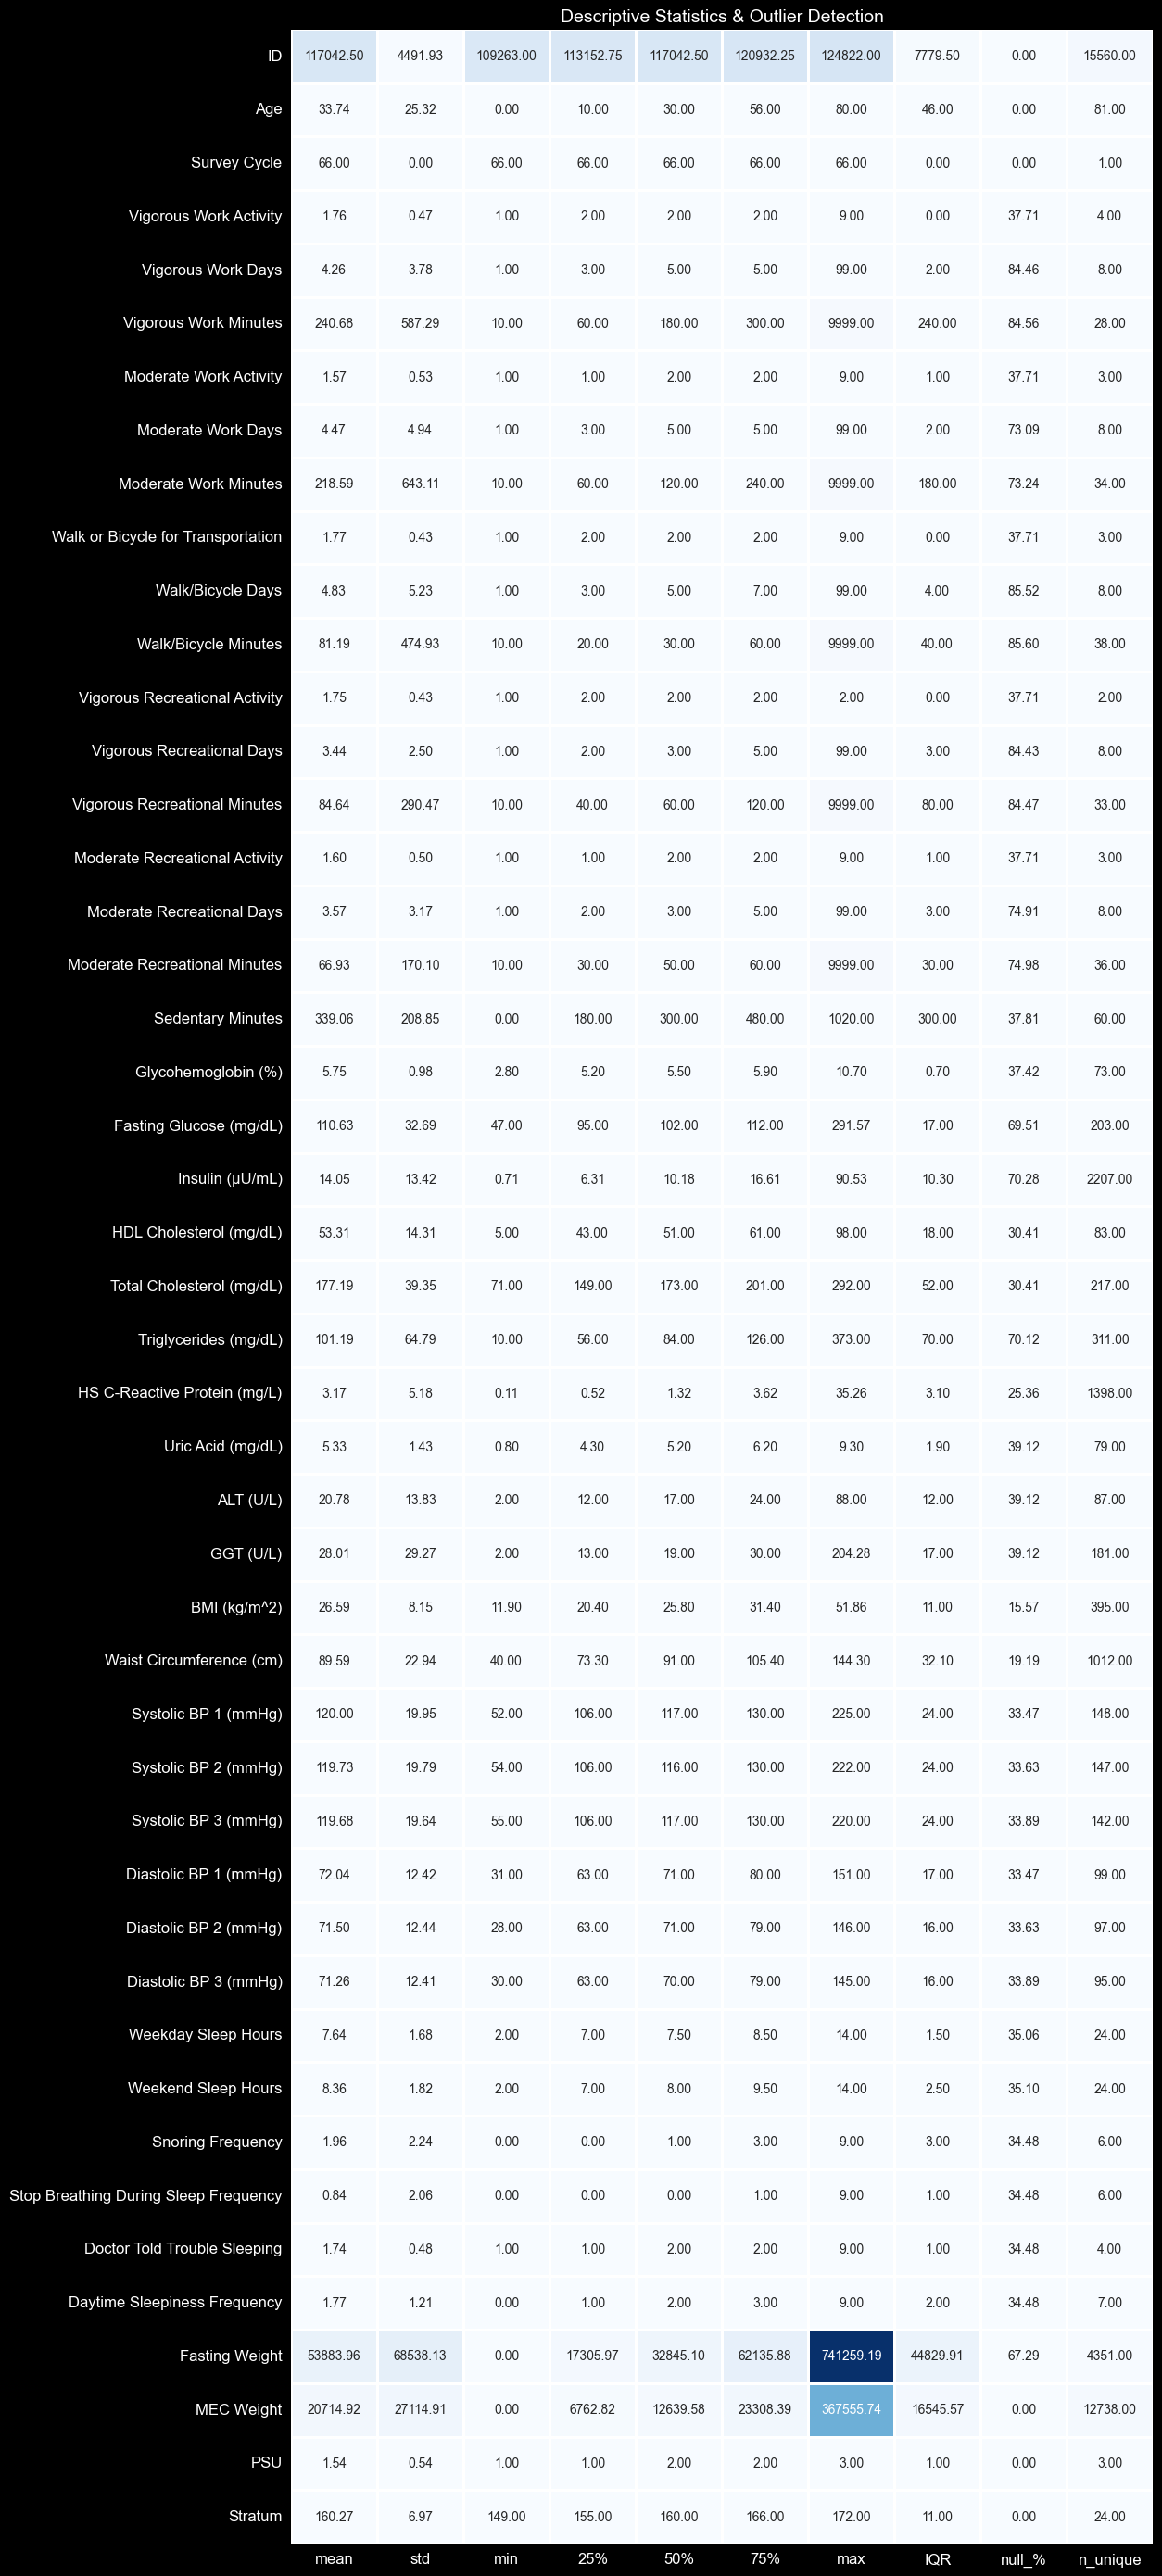

In [15]:
def analyze_df(df, include_corr=False, return_summary=False):
    """
    Analyze a numeric DataFrame: summarize statistics, detect outliers, and visualize via heatmap.

    Parameters:
    - df: pandas DataFrame with only numerical columns
    - include_corr: if True, displays a correlation heatmap
    - return_summary: if True, returns the summary DataFrame

    Returns:
    - summary DataFrame
    """
    # Validate input
    if not isinstance(df, pd.DataFrame):
        raise ValueError("Input must be a pandas DataFrame.")

    numeric_df = df.select_dtypes(include=[float, int])
    if numeric_df.empty:
        raise ValueError("No numeric columns found in the DataFrame.")

    desc = numeric_df.describe().T

    # Compute IQR and outlier bounds
    desc['IQR'] = desc['75%'] - desc['25%']
    desc['null_%'] = (numeric_df.isnull().sum()/len(numeric_df)) * 100
    desc['n_unique'] = numeric_df.nunique()
    desc['max_outlier'] = numeric_df.max() > (desc['75%'] + 1.5 * desc['IQR'])
    desc['min_outlier'] = numeric_df.min() < (desc['25%'] - 1.5 * desc['IQR'])

    # Select relevant columns for visualization
    vis_df = desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR', 'null_%', 'n_unique']].astype(float)

    # Plot heatmap
    plt.figure(figsize=(12, vis_df.shape[0] * 0.75))
    sns.heatmap(vis_df,
                annot=True,
                cmap="Blues",
                fmt=".2f",
                linecolor="white",
                linewidths=1,
                cbar=False,
                annot_kws={"size": 10})

    plt.xticks(size=12)
    plt.yticks(size=12, rotation=0)
    plt.title("Descriptive Statistics & Outlier Detection", size=14)
    plt.show()

    # correlation heatmap
    if include_corr:
        corr = numeric_df.corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Matrix", size=14)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.show()

    if return_summary:
        return desc

analyze_df(analysis_df)

In [16]:
def cat_missing(df: pd.DataFrame) -> dict:
    """
    Categorise every column in df by its percentage of missing values.

    Bins
    ----
    0-5%   : very low missingness
    5-10%  : low missingness
    10-20% : moderate missingness
    20-50% : high missingness
    50%+   : very high missingness

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    dict mapping bin label -> list of column names
    """
    null_pct = df.isnull().mean() * 100

    bins = {
        "0-5%   (very low)":    [],
        "5-10%  (low)":         [],
        "10-20% (moderate)":    [],
        "20-50% (high)":        [],
        "50%+   (very high)":   [],
    }

    for col, pct in null_pct.items():
        if pct <= 5:
            bins["0-5%   (very low)"].append(col)
        elif pct <= 10:
            bins["5-10%  (low)"].append(col)
        elif pct <= 20:
            bins["10-20% (moderate)"].append(col)
        elif pct <= 50:
            bins["20-50% (high)"].append(col)
        else:
            bins["50%+   (very high)"].append(col)

    for label, cols in bins.items():
        print(f"\n{label} — {len(cols)} column(s):")
        for c in cols:
            print(f"    {c:40s}  {null_pct[c]:.1f}% missing")

In [17]:
cat_missing(analysis_df)


0-5%   (very low) — 7 column(s):
    ID                                        0.0% missing
    Age                                       0.0% missing
    Sex                                       0.0% missing
    Survey Cycle                              0.0% missing
    MEC Weight                                0.0% missing
    PSU                                       0.0% missing
    Stratum                                   0.0% missing

5-10%  (low) — 0 column(s):

10-20% (moderate) — 2 column(s):
    BMI (kg/m^2)                              15.6% missing
    Waist Circumference (cm)                  19.2% missing

20-50% (high) — 29 column(s):
    Vigorous Work Activity                    37.7% missing
    Moderate Work Activity                    37.7% missing
    Walk or Bicycle for Transportation        37.7% missing
    Vigorous Recreational Activity            37.7% missing
    Moderate Recreational Activity            37.7% missing
    Sedentary Minutes                  

In [18]:
# create average Blood Pressure Feature:

analysis_df["Average_Systolic_BP (mmHg)"] = analysis_df[[
    "Systolic BP 1 (mmHg)",
    "Systolic BP 2 (mmHg)",
    "Systolic BP 3 (mmHg)"
]].mean(axis=1, skipna= True)

analysis_df["Average_Diastolic_BP (mmHg)"] = analysis_df[[
    "Diastolic BP 1 (mmHg)",
    "Diastolic BP 2 (mmHg)",
    "Diastolic BP 3 (mmHg)"
]].mean(axis=1, skipna = True)

In [19]:
# filtering analysis_df to include a simple set of potential features related to lifestyle in this population.

# simple list:

s_list = [
    'ID',
    'Age',
    'Sex',
    'BMI (kg/m^2)',
    'Waist Circumference (cm)',
    'Survey Cycle',
    'Vigorous Work Activity',
    'Moderate Work Activity',
    'Walk or Bicycle for Transportation',
    'Sedentary Minutes',
    'Glycohemoglobin (%)',
    'HDL Cholesterol (mg/dL)',
    'Total Cholesterol (mg/dL)',
    'HS C-Reactive Protein (mg/L)',
    'Uric Acid (mg/dL)',
    'ALT (U/L)',
    'GGT (U/L)',
    'Average_Systolic_BP (mmHg)',
    'Average_Diastolic_BP (mmHg)',

    'Fasting Glucose (mg/dL)',
    'Insulin (µU/mL)',
    'Triglycerides (mg/dL)',


    "Fasting Weight",
    "PSU",
    "Stratum",
    "MEC Weight",

]

# filtering analysis df:

simple_df = analysis_df[s_list].copy()

simple_df.head()

,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Survey Cycle,Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,...,GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),Fasting Glucose (mg/dL),Insulin (µU/mL),Triglycerides (mg/dL),Fasting Weight,PSU,Stratum,MEC Weight
0,109263,2,Male,NaN,NaN,66.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,156.0,8951.815567
1,109264,13,Female,17.6,63.8,66.0,NaN,NaN,NaN,NaN,...,12.0,108.0,67.000000,97.0,6.05,40.0,27533.174559,1.0,155.0,12271.157043
2,109265,2,Male,15.0,41.2,66.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,157.0,16658.764203
3,109266,29,Female,37.8,117.9,66.0,2.0,2.0,2.0,480.0,...,8.0,99.0,54.333333,NaN,NaN,NaN,NaN,2.0,168.0,8154.968193
4,109267,21,Female,NaN,NaN,66.0,2.0,2.0,2.0,540.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,156.0,0.000000


### Checking if missingness if column specific

In [20]:
# find unique values for Survey Cycle:

simple_df['Survey Cycle'].unique()

array([66.])

In [21]:
# check missingness through binned age groups:

simple_df.assign(
    age_group=pd.cut(
        analysis_df["Age"],
        bins=[0, 18, 40, 60, 80, 120],
        labels=["0-17", "18-39", "40-59", "60-79", "80+"]
    )
).groupby("age_group")[s_list].apply(lambda df: df.isna().mean().mul(100))

/var/folders/4m/kdq4gwhn11n3lfm86db37d_h0000gn/T/ipykernel_51301/1415072713.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby("age_group")[s_list].apply(lambda df: df.isna().mean().mul(100))


,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Survey Cycle,Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,...,GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),Fasting Glucose (mg/dL),Insulin (µU/mL),Triglycerides (mg/dL),Fasting Weight,PSU,Stratum,MEC Weight
age_group,,,,,,,,,,,,,,,,,,,,,
0-17,0.0,0.0,0.0,17.495929,21.675412,0.0,95.766238,95.766238,95.766238,95.766238,...,74.579338,54.405645,54.405645,88.149086,88.637597,88.547132,86.484530,0.0,0.0,0.0
18-39,0.0,0.0,0.0,8.593997,11.816746,0.0,0.000000,0.000000,0.000000,0.315956,...,14.976303,17.756714,17.756714,57.661927,58.546603,58.388626,54.786730,0.0,0.0,0.0
40-59,0.0,0.0,0.0,7.893041,10.405928,0.0,0.000000,0.000000,0.000000,0.128866,...,13.273196,15.399485,15.399485,55.380155,56.282216,56.153351,52.996134,0.0,0.0,0.0
60-79,0.0,0.0,0.0,11.442006,16.206897,0.0,0.000000,0.000000,0.000000,0.094044,...,15.830721,18.369906,18.369906,57.241379,58.369906,58.025078,54.451411,0.0,0.0,0.0
80+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Create analytic dataframe
# We keep adults 18+ because the MetS criteria are adult criteria.
# We do not restrict to 18-59 just to reduce missingness.

analytic_df = simple_df.copy()

analytic_df = analytic_df[
    analytic_df["Age"] >= 18
].copy()

# Encode sex variable
analytic_df["Sex"] = analytic_df["Sex"].map({"Male": 1, "Female": 0}).astype("float64")

analytic_df.head()


,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Survey Cycle,Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,...,GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),Fasting Glucose (mg/dL),Insulin (µU/mL),Triglycerides (mg/dL),Fasting Weight,PSU,Stratum,MEC Weight
3,109266,29,0.0,37.8,117.9,66.0,2.0,2.0,2.0,480.0,...,8.0,99.000000,54.333333,NaN,NaN,NaN,NaN,2.0,168.0,8154.968193
4,109267,21,0.0,NaN,NaN,66.0,2.0,2.0,2.0,540.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,156.0,0.000000
5,109268,18,0.0,NaN,NaN,66.0,1.0,1.0,2.0,540.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,155.0,0.000000
8,109271,49,1.0,29.7,120.4,66.0,2.0,1.0,2.0,60.0,...,12.0,107.000000,67.000000,103.0,16.96,84.0,18100.965319,1.0,167.0,8658.732873
10,109273,36,1.0,21.9,86.8,66.0,1.0,2.0,2.0,180.0,...,19.0,113.666667,67.333333,NaN,NaN,NaN,NaN,1.0,155.0,22163.596850


### NHANES MEC, Fasting Subsample, and Survey Weights

In NHANES, participants first complete an interview, and many then attend a Mobile Examination Center (MEC), where physical measurements and lab data are collected. MEC-based variables include measures such as BMI, waist circumference, blood pressure, HbA1c, HDL cholesterol, CRP, and total cholesterol.

Some biomarkers, such as fasting glucose, insulin, and triglycerides, are only collected from a smaller fasting subsample because participants must fast before these measurements. This means **missingness in these fasting variables is partly due to NHANES study design, not necessarily poor data quality.**

**Why are the weights important ?**

NHANES provides different survey weights for these groups. The MEC weight is used for variables collected from the broader exam sample, while the fasting weight is used for variables collected from the smaller fasting subsample. These weights **help account for the fact that each participant represents a portion of the broader US population, not just one row in the dataset**.

In this notebook, the weights are kept in the cleaned data so they can be used later when summarizing or interpreting results. They are not treated as health features and should not be scaled, clustered, or used as metabolic biomarkers. Instead, they help us interpret whether results describe only the analytic sample or can be generalized more carefully to the broader US adult population.

Example:

- Person A: BMI = 25, weight = 10,000
- Person B: BMI = 30, weight = 20,000
- Person C: BMI = 35, weight = 70,000

A normal unweighted mean would be: (25 + 30 + 35) / 3 = 30

But a weighted mean would give Person C more influence because they represent more people in the US population:

(25 × 10,000 + 30 × 20,000 + 35 × 70,000) / (10,000 + 20,000 + 70,000)

In [23]:
def check_survey_design_columns(df, weight_cols=None, design_cols=None):
    """
    Summarizes NHANES survey weight and design columns for missingness and validity.
    Returns separate checks for weight columns and survey design columns.
    """
    if weight_cols is None:
        weight_cols = ["Fasting Weight", "MEC Weight"]

    if design_cols is None:
        design_cols = ["PSU", "Stratum"]

    weight_check = df[weight_cols].agg(["count", "nunique", "min", "max"]).T
    weight_check["missing_%"] = df[weight_cols].isna().mean() * 100
    weight_check["zero_n"] = df[weight_cols].eq(0).sum()
    weight_check["positive_n"] = df[weight_cols].gt(0).sum()

    design_check = df[design_cols].agg(["count", "nunique", "min", "max"]).T
    design_check["missing_%"] = df[design_cols].isna().mean() * 100

    display(weight_check)
    display(design_check)

    return weight_check, design_check

In [24]:
weight_check, design_check = check_survey_design_columns(analytic_df)

,count,nunique,min,max,missing_%,zero_n,positive_n
Fasting Weight,4438.0,3907.0,0.0,741259.188749,54.214382,482,3956
MEC Weight,9693.0,8367.0,0.0,367555.742979,0.000000,728,8965


,count,nunique,min,max,missing_%
PSU,9693.0,3.0,1.0,3.0,0.0
Stratum,9693.0,24.0,149.0,172.0,0.0


In [25]:
# exploring missing data in analytic_df:

# code taken from unsupervised section

missing = (
    analytic_df
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print(missing)

Insulin (µU/mL)                       0.579181
Triglycerides (mg/dL)                 0.577014
Fasting Glucose (mg/dL)               0.569483
Fasting Weight                        0.542144
Average_Systolic_BP (mmHg)            0.172186
Average_Diastolic_BP (mmHg)           0.172186
HS C-Reactive Protein (mg/L)          0.150211
Uric Acid (mg/dL)                     0.148354
ALT (U/L)                             0.148354
GGT (U/L)                             0.148354
HDL Cholesterol (mg/dL)               0.143918
Total Cholesterol (mg/dL)             0.143918
Waist Circumference (cm)              0.128340
Glycohemoglobin (%)                   0.126793
BMI (kg/m^2)                          0.093160
Sedentary Minutes                     0.001754
PSU                                   0.000000
Stratum                               0.000000
ID                                    0.000000
Age                                   0.000000
Walk or Bicycle for Transportation    0.000000
Moderate Work

### dataframe with only the metS variables (sensitivity analysis)

In [26]:
# Dataframe with only the MetS variables
# This is a fasting sub-sample sensitivity analysis.

mets_features = [
    "ID",
    "Waist Circumference (cm)",
    "Triglycerides (mg/dL)",
    "Average_Systolic_BP (mmHg)",
    "Average_Diastolic_BP (mmHg)",
    "HDL Cholesterol (mg/dL)",
    "Fasting Glucose (mg/dL)"
]

mets_design_cols = ["Fasting Weight", "PSU", "Stratum"]

# Keep only adults with a valid fasting weight.
metS_df = analytic_df.loc[
    analytic_df["Fasting Weight"].notna() & (analytic_df["Fasting Weight"] > 0),
    mets_features + mets_design_cols
].copy()

missing_before = (
    metS_df[mets_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("Missingness before feature drop:")
print(missing_before)

print(f"Shape before feature dropna: {metS_df.shape}")

# Drop rows only if they are missing the actual MetS features.
metS_df = metS_df.dropna(subset=mets_features).copy()

print(f"Shape after feature dropna: {metS_df.shape}")

missing_after = (
    metS_df[mets_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("Missingness after feature drop:")
print(missing_after)

metS_df.head()


Missingness before feature drop:
Average_Systolic_BP (mmHg)     0.091001
Average_Diastolic_BP (mmHg)    0.091001
Waist Circumference (cm)       0.040192
Triglycerides (mg/dL)          0.016936
HDL Cholesterol (mg/dL)        0.016936
ID                             0.000000
Fasting Glucose (mg/dL)        0.000000
dtype: float64
Shape before feature dropna: (3956, 10)
Shape after feature dropna: (3460, 10)
Missingness after feature drop:
ID                             0.0
Waist Circumference (cm)       0.0
Triglycerides (mg/dL)          0.0
Average_Systolic_BP (mmHg)     0.0
Average_Diastolic_BP (mmHg)    0.0
HDL Cholesterol (mg/dL)        0.0
Fasting Glucose (mg/dL)        0.0
dtype: float64


,ID,Waist Circumference (cm),Triglycerides (mg/dL),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),HDL Cholesterol (mg/dL),Fasting Glucose (mg/dL),Fasting Weight,PSU,Stratum
8,109271,120.4,84.0,107.000000,67.000000,33.0,103.0,18100.965319,1.0,167.0
11,109274,109.6,133.0,134.000000,70.000000,29.0,154.0,16281.758327,2.0,167.0
27,109290,92.0,102.0,121.333333,60.333333,40.0,106.0,8548.619835,1.0,171.0
34,109297,73.2,44.0,104.000000,69.666667,82.0,92.0,29933.457486,2.0,154.0
37,109300,84.8,50.0,162.333333,94.000000,63.0,103.0,49174.160468,1.0,169.0


#### MEC (Mobile Examination Center) analytic Dataframe:

In [27]:
# Non-fasting / MEC analytic dataframe
# This dataframe excludes fasting biomarkers and uses the broader MEC sample.

mec_features = [
    "ID",
    "Age",
    "Sex",
    "BMI (kg/m^2)",
    "Waist Circumference (cm)",
    "Vigorous Work Activity",
    "Moderate Work Activity",
    "Walk or Bicycle for Transportation",
    "Sedentary Minutes",
    "Glycohemoglobin (%)",
    "HDL Cholesterol (mg/dL)",
    "Total Cholesterol (mg/dL)",
    "HS C-Reactive Protein (mg/L)",
    "Uric Acid (mg/dL)",
    "ALT (U/L)",
    "GGT (U/L)",
    "Average_Systolic_BP (mmHg)",
    "Average_Diastolic_BP (mmHg)"
]

mec_design_cols = ["MEC Weight", "PSU", "Stratum"]

# Keep only adults with a valid MEC weight.
cardio_met = analytic_df.loc[
    analytic_df["MEC Weight"].notna() & (analytic_df["MEC Weight"] > 0),
    mec_features + mec_design_cols
].copy()

print(f"Shape before feature dropna: {cardio_met.shape}")

# Drop rows only if they are missing the actual analysis features.
# Do not drop based on fasting weight, because this is not a fasting-subsample dataframe.
cardio_met = cardio_met.dropna(subset=mec_features).copy()

print(f"Shape after feature dropna: {cardio_met.shape}")

cardio_met.head()

Shape before feature dropna: (8965, 21)
Shape after feature dropna: (7207, 21)


,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),...,Total Cholesterol (mg/dL),HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),MEC Weight,PSU,Stratum
3,109266,29,0.0,37.8,117.9,2.0,2.0,2.0,480.0,5.2,...,195.0,0.72,4.9,15.0,8.0,99.000000,54.333333,8154.968193,2.0,168.0
8,109271,49,1.0,29.7,120.4,2.0,1.0,2.0,60.0,5.6,...,147.0,28.68,5.0,8.0,12.0,107.000000,67.000000,8658.732873,1.0,167.0
10,109273,36,1.0,21.9,86.8,1.0,2.0,2.0,180.0,5.1,...,164.0,0.98,5.2,35.0,19.0,113.666667,67.333333,22163.596850,1.0,155.0
11,109274,68,1.0,30.2,109.6,1.0,1.0,1.0,300.0,5.7,...,105.0,1.60,5.1,19.0,16.0,134.000000,70.000000,7801.600218,2.0,167.0
27,109290,68,0.0,28.1,92.0,2.0,1.0,1.0,180.0,8.4,...,165.0,0.25,4.2,19.0,30.0,121.333333,60.333333,4099.841985,1.0,171.0


In [28]:
missing = (
    cardio_met
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print(missing)

ID                                    0.0
Total Cholesterol (mg/dL)             0.0
PSU                                   0.0
MEC Weight                            0.0
Average_Diastolic_BP (mmHg)           0.0
Average_Systolic_BP (mmHg)            0.0
GGT (U/L)                             0.0
ALT (U/L)                             0.0
Uric Acid (mg/dL)                     0.0
HS C-Reactive Protein (mg/L)          0.0
HDL Cholesterol (mg/dL)               0.0
Age                                   0.0
Glycohemoglobin (%)                   0.0
Sedentary Minutes                     0.0
Walk or Bicycle for Transportation    0.0
Moderate Work Activity                0.0
Vigorous Work Activity                0.0
Waist Circumference (cm)              0.0
BMI (kg/m^2)                          0.0
Sex                                   0.0
Stratum                               0.0
dtype: float64


In [29]:
cardio_met.shape

(7207, 21)

In [30]:
print("ID in simple_df:", "ID" in simple_df.columns)
print("ID in analytic_df:", "ID" in analytic_df.columns)
print("ID in cardio_met:", "ID" in cardio_met.columns)
print("ID in metS_df:", "ID" in metS_df.columns)

ID in simple_df: True
ID in analytic_df: True
ID in cardio_met: True
ID in metS_df: True


## Supervised Learning

To understand how demographic, physical activity and metabolic health variables can predic an individual's phenotype classification, we have selected Logistic Regression, Random Forest and XGBoost to capture the variables relationships and behavior.

We will run a supervised learning model on a broaders set of manually selected variables, and then again utilizing the varibales idenitified in the unsupervised learning model analysis. A comparison of the two results will determine if  phenotype membership improves prediction
beyond individual variables.

#### Feature Selection

In [31]:
# Standardize Tuning of Supervised Learning Model
RANDOM_STATE = 42
TEST_SIZE = 0.20

In [32]:
# Identify supervised model variable selection, dataframe, and target variable.

target_col = "SLQ050"
sl_df = cardio_met.copy()

# Include sleep outcome from analytic_df on ID
sleep_outcome = master_df[["SEQN", target_col]].copy()
sleep_outcome = sleep_outcome.rename(columns={"SEQN": "ID"})

sl_df = sl_df.merge(
    sleep_outcome,
    on="ID",
    how="inner"
)

# Ensure sleep disorder responses are either 1 or 2
sl_df = sl_df[sl_df[target_col].isin([1, 2])].copy()

sl_df[target_col] = sl_df[target_col].map({
    1: 1, # sleep disorder
    2: 0  # no sleep disorder
})

# Feature selection
sl_features = mec_features.copy()
sl_features = [col for col in sl_features if col != "ID"]

X = sl_df[sl_features]
y = sl_df[target_col]

sl_df.head()


,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),...,HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),MEC Weight,PSU,Stratum,SLQ050
0,109266,29,0.0,37.8,117.9,2.0,2.0,2.0,480.0,5.2,...,0.72,4.9,15.0,8.0,99.000000,54.333333,8154.968193,2.0,168.0,0
1,109271,49,1.0,29.7,120.4,2.0,1.0,2.0,60.0,5.6,...,28.68,5.0,8.0,12.0,107.000000,67.000000,8658.732873,1.0,167.0,1
2,109273,36,1.0,21.9,86.8,1.0,2.0,2.0,180.0,5.1,...,0.98,5.2,35.0,19.0,113.666667,67.333333,22163.596850,1.0,155.0,1
3,109274,68,1.0,30.2,109.6,1.0,1.0,1.0,300.0,5.7,...,1.60,5.1,19.0,16.0,134.000000,70.000000,7801.600218,2.0,167.0,0
4,109290,68,0.0,28.1,92.0,2.0,1.0,1.0,180.0,8.4,...,0.25,4.2,19.0,30.0,121.333333,60.333333,4099.841985,1.0,171.0,0


In [33]:
print("Dataset Summary:")

print(f"Observations: {len(sl_df):,}")
print(f"Predictors: {len(sl_features)}")

print(f"\nX Shape: {X.shape}")
print(f"y Shape: {y.shape}")

Dataset Summary:
Observations: 7,204
Predictors: 17

X Shape: (7204, 17)
y Shape: (7204,)


#### Class Imbalance

In [34]:
# Target Distribution - check for imbalance

def target_distribution(df):
    """
    Split predictors and target into stratified training and test sets.

    Parameters:
    - Supervised learning dataframe

    Returns:
    - Target variables count and percentage dataframe
    """

    target_dist = pd.DataFrame({
        "Count": y.value_counts(),
        "Percent": round(y.value_counts(normalize=True) * 100, 2)
    })

    target_dist.index = [
        "No Sleep Disorder (0)",
        "Sleep Disorder (1)"
    ]

    master_sleep = master_df[
    master_df["SLQ050"].isin([1, 2])
    ].copy()

    master_sleep["SLQ050"] = master_sleep["SLQ050"].map({
        1: 1,  # Sleep Disorder
        2: 0   # No Sleep Disorder
    })

    comparison_df = pd.DataFrame({
        "Original (%)": round(
            master_sleep["SLQ050"].value_counts(
                normalize=True
            ) * 100,
            2
        ),
        "Dropped Missing Values (%)": round(
            sl_df["SLQ050"].value_counts(
                normalize=True
            ) * 100,
            2
        )
    })

    display(comparison_df)

    return target_dist

target_distribution(sl_df)

,Original (%),Dropped Missing Values (%)
SLQ050,,
0,73.12,71.24
1,26.88,28.76


,Count,Percent
No Sleep Disorder (0),5132,71.24
Sleep Disorder (1),2072,28.76


A comparison of the target variable distribution before and after dropping missing values was conducted to assess whether case-wise deletion introduced  bias. The proportion of participants with sleep disorder changed only slightly, from 26.9% in the original dataset to 28.8% in the supervised learning dataset. Although the final dataset shows some class imbalance (71.2% vs. 28.8%), the imbalance was not severe enough to utilize synethetic data techniques like SMOTE.

In [35]:
# Ensure sl_df has no missing value
sl_df.isnull().sum()

ID                                    0
Age                                   0
Sex                                   0
BMI (kg/m^2)                          0
Waist Circumference (cm)              0
Vigorous Work Activity                0
Moderate Work Activity                0
Walk or Bicycle for Transportation    0
Sedentary Minutes                     0
Glycohemoglobin (%)                   0
HDL Cholesterol (mg/dL)               0
Total Cholesterol (mg/dL)             0
HS C-Reactive Protein (mg/L)          0
Uric Acid (mg/dL)                     0
ALT (U/L)                             0
GGT (U/L)                             0
Average_Systolic_BP (mmHg)            0
Average_Diastolic_BP (mmHg)           0
MEC Weight                            0
PSU                                   0
Stratum                               0
SLQ050                                0
dtype: int64

#### Model Training (train/test split)

In [36]:
# Train / Test Split

def test_train_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    """
    Train / test data split

    Parameters:
    - X: predictor variables (dataframe)
    - y: target variable (sleep disorder)
    - test_size: default = 0.2
    - random_state: default = 42

    Returns:
    - X_train: sl_features used to train the model
    - X_test: sl_features used to evaluate the model
    - y_train: sleep-disorder labels corresponding to X_train
    - y_test: sleep-disorder labels corresponding to X_test

    """
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )


    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = test_train_split(X, y)

#### Preprocessor pipeline

In [37]:
# Build the preprocessing pipeline by separating numeric and categorical

def preprocessor_pipeline(X):
    """
    Preprocessing pipeline for the supervised learning predictors

    Parameters
    - X: sl_df (dataframe with predictor variables used for training the model)

    Returns
    - preprocessor: ColumnTransformer preprocessor
    - numeric_features:  list of numeric predictor variables
    - categorical_features : list of categorical predictor variables
    """

    # Identify feature types
    numeric_features = X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # Numeric preprocessing
    numeric_transformer = Pipeline(steps=[
        ("scaler", StandardScaler())
    ])

    # Categorical preprocessing
    categorical_transformer = Pipeline(steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    # Preprocessing steps combined
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor, numeric_features, categorical_features

preprocessor_pipeline(X)

(ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('scaler', StandardScaler())]),
                                  ['Age', 'Sex', 'BMI (kg/m^2)',
                                   'Waist Circumference (cm)',
                                   'Vigorous Work Activity',
                                   'Moderate Work Activity',
                                   'Walk or Bicycle for Transportation',
                                   'Sedentary Minutes', 'Glycohemoglobin (%)',
                                   'HDL Cholesterol (mg/dL)',
                                   'Total Cholesterol (mg/dL)',
                                   'HS C-Reactive Protein (mg/L)',
                                   'Uric Acid (mg/dL)', 'ALT (U/L)', 'GGT (U/L)',
                                   'Average_Systolic_BP (mmHg)',
                                   'Average_Diastolic_BP (mmHg)']),
                                 ('cat',
                          

#### Supervised Learning Models

We selected **Logistic Regression**, **Random Forest**, and **XGBoost** to compare a linear baseline against more flexible tree-based methods. Logistic Regression served as an interpretable probabilistic baseline, while Random Forest and XGBoost were chosen because they are strong tree-based models that can capture non-linear relationships and interactions among predictors without requiring strict distributional assumptions. Initial hyperparameter settings were specified for each model, and these were later refined using **GridSearchCV**.

In [38]:
# Process Model
def supervisedlearning_models(preprocessor):
    """
    Supervised learning pipelines for sleep disorder prediction

    Parameters
    - preprocessor: Preprocessing pipeline applied before model training

    Returns
    - model: Random Forest and XGBoost model pipelines
    """
    logreg_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=2000
        ))
    ])

    rf_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state= RANDOM_STATE,
            n_jobs = -1
        ))
    ])

    xgb_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state= RANDOM_STATE
        ))
    ])

    models = {
        "Logistic Regression": logreg_model,
        "Random Forest": rf_model,
        "XGBoost": xgb_model
    }

    return models

models = supervisedlearning_models(preprocessor_pipeline(X)[0])

#### Hyperparameter Analysis

**GridSearchCV** was utilized to test multiple hyperparameter combinations and find the best settings for each model based on cross-validated F1 score.

In [39]:
# Utilize GridSearchCV to select best hyperparameters for each model

def gridsearch_models(models, X_train, y_train, cv=5, scoring="f1"):
    """
    Fine-tune supervised learning hyperparaters with GridSearchCV

    Parameters:
    - model: Model pipeline to tune
    - X_train: Training features
    - y_train: Training target values
    - cv: Number of cross-validation folds
    - scoring: Scoring metric used for model selection.

    Returns:
    - best_model: Best fitted model from GridSearchCV
    - best_params: Best hyperparameters
    """
    param_grids = {
      "Logistic Regression": {
          "classifier__C": [0.01, 0.1, 1, 10],
          "classifier__penalty": ["l1", "l2"],
          "classifier__solver": ["liblinear"],
          "classifier__class_weight": [None, "balanced"]
      },
      "Random Forest": {
          "classifier__n_estimators": [100, 300],
          "classifier__max_depth": [None, 5, 10],
          "classifier__min_samples_split": [2, 5],
          "classifier__min_samples_leaf": [1, 2],
          "classifier__class_weight": [None, "balanced"]
      },
      "XGBoost": {
          "classifier__n_estimators": [100, 300],
          "classifier__learning_rate": [0.05, 0.1],
          "classifier__max_depth": [3, 5],
          "classifier__subsample": [0.8, 1.0],
          "classifier__colsample_bytree": [0.8, 1.0]
      }
    }

    best_models = {}
    results = []

    for model_name, model in models.items():
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        grid_search.fit(X_train, y_train)

        best_models[model_name] = grid_search.best_estimator_

        results.append({
            "Model": model_name,
            "Best CV F1": round(grid_search.best_score_, 3),
            "Best Parameters": str(grid_search.best_params_)
        })

    results_df = pd.DataFrame(results)

    return best_models, results_df

Utilizing the best estimators, we will run the gridsearch model.

Please note, this cell will take somwhere around **6 minutes** to run as it is running through both models, multiple parameter combinations and cross validation folds.

In [40]:
# Input best estimators in the supervised learning models
models = supervisedlearning_models(preprocessor_pipeline(X)[0])

best_models, results_df = gridsearch_models(
  models = models,
  X_train = X_train,
  y_train = y_train,
  cv = 5,
  scoring = "f1"
)

results_df

,Model,Best CV F1,Best Parameters
0,Logistic Regression,0.476,"{'classifier__C': 0.1, 'classifier__class_weig..."
1,Random Forest,0.464,"{'classifier__class_weight': 'balanced', 'clas..."
2,XGBoost,0.242,"{'classifier__colsample_bytree': 0.8, 'classif..."


From our results, we noticed that even with the various hyperparameter combinations tested, the overall model performance remained moderate.
Possible causation may be due to limited sample size, overlapping group characteristics or weak predictive features.

Based on the cross-validated F1 scores, Logistic Regression performed the best, and Random Forest performed better than XGBoost.

#### Cross-validation

In [41]:
# Use cross-validation to compare model performance and see
# how well each model generalizes across cv

def crossval_summary(models, X, y, cv=5):
    """
    Evaluate mean and standard deviation across 5-fold CV
    """
    scoring = {
        "f1": "f1",
        "precision": "precision",
        "recall": "recall",
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc"
    }

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    rows = []

    for model_name, model in models.items():
        scores = cross_validate(
            model,
            X,
            y,
            cv=skf,
            scoring=scoring,
            n_jobs=-1
        )

        rows.append({
            "Model": model_name,
            "F1 Mean": scores["test_f1"].mean(),
            "F1 SD": scores["test_f1"].std(),
            "Precision Mean": scores["test_precision"].mean(),
            "Precision SD": scores["test_precision"].std(),
            "Recall Mean": scores["test_recall"].mean(),
            "Recall SD": scores["test_recall"].std(),
            "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
            "Balanced Accuracy SD": scores["test_balanced_accuracy"].std(),
            "AUROC Mean": scores["test_roc_auc"].mean(),
            "AUROC SD": scores["test_roc_auc"].std()
        })

    return pd.DataFrame(rows).round(3)

In [42]:
# Call crossval_summary
cv_summary_df = crossval_summary(best_models, X_train, y_train, cv=5)
cv_summary_df

,Model,F1 Mean,F1 SD,Precision Mean,Precision SD,Recall Mean,Recall SD,Balanced Accuracy Mean,Balanced Accuracy SD,AUROC Mean,AUROC SD
0,Logistic Regression,0.476,0.027,0.386,0.020,0.620,0.043,0.611,0.024,0.651,0.030
1,Random Forest,0.463,0.031,0.395,0.021,0.559,0.052,0.607,0.025,0.644,0.032
2,XGBoost,0.256,0.026,0.422,0.054,0.184,0.017,0.541,0.014,0.603,0.020


The 5-fold cross-validation results showed that Logistic Regression was the best-performing supervised model overall, with the highest F1 score (0.476), recall (0.620), balanced accuracy (0.611), and AUROC (0.651), while also showing relatively low standard deviation across folds. Random Forest performed similarly but slightly worse on most metrics, whereas XGBoost performed substantially worse, particularly in recall and F1. Given these findings, we believe that the relationship between the selected predictors and sleep disorder may be captured reasonably well by a simpler linear model, rather than requiring a more complex tree-based approach.

#### Model Evaluation

In [43]:
# Run Model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, threshold=0.40):
    """
    Train supervised learning models and evaluate its test performance

    Parameters
    - model: preprocessing and classifier steps
    - X_train: train feature dataset
    - X_test: testing feature dataset
    - y_train: training target labels
    - y_test: testing target labels
    - model_name: name of the model being evaluated

    Returns
    - results: model performance metrics
    - model: trained model pipeline
    """
    # Train model
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "AUROC": roc_auc_score(y_test, y_proba),
    }

    return results, model, y_pred, y_proba


In [44]:
# Evaluate tuned Logistic Regression, Random Forest and XGBoost models

lr_results, lr_model, lr_pred, lr_proba = evaluate_model(
    model=best_models["Logistic Regression"],
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Logistic Regression",
    threshold=0.40
)

rf_results, rf_model, rf_pred, rf_proba = evaluate_model(
    model=best_models["Random Forest"],
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Random Forest",
    threshold=0.40
)

xgb_results, xgb_model, xgb_pred, xgb_proba = evaluate_model(
    model=best_models["XGBoost"],
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="XGBoost",
    threshold=0.40
)

model_comparison_df = pd.DataFrame([lr_results, rf_results, xgb_results]).round(3)

model_comparison_df

,Model,Threshold,Balanced Accuracy,Precision,Recall,F1 Score,AUROC
0,Logistic Regression,0.4,0.576,0.329,0.860,0.476,0.638
1,Random Forest,0.4,0.570,0.326,0.843,0.470,0.630
2,XGBoost,0.4,0.559,0.396,0.307,0.346,0.610


In [45]:
# Compare performance score across all three models

def model_comparison(model_comparison_df):
    """
    Compare model performance across evaluation metrics
    """

    metric_cols = [
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUROC"
    ]

    ax = model_comparison_df.set_index("Model")[metric_cols].T.plot(
        kind="bar",
        figsize=(10, 6),
        color=["#4E79A7", "#EFCB68", "#9E9E9E"]
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

    plt.ylabel("Score")
    plt.xlabel("Metric")
    plt.title("Model Performance Comparison")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

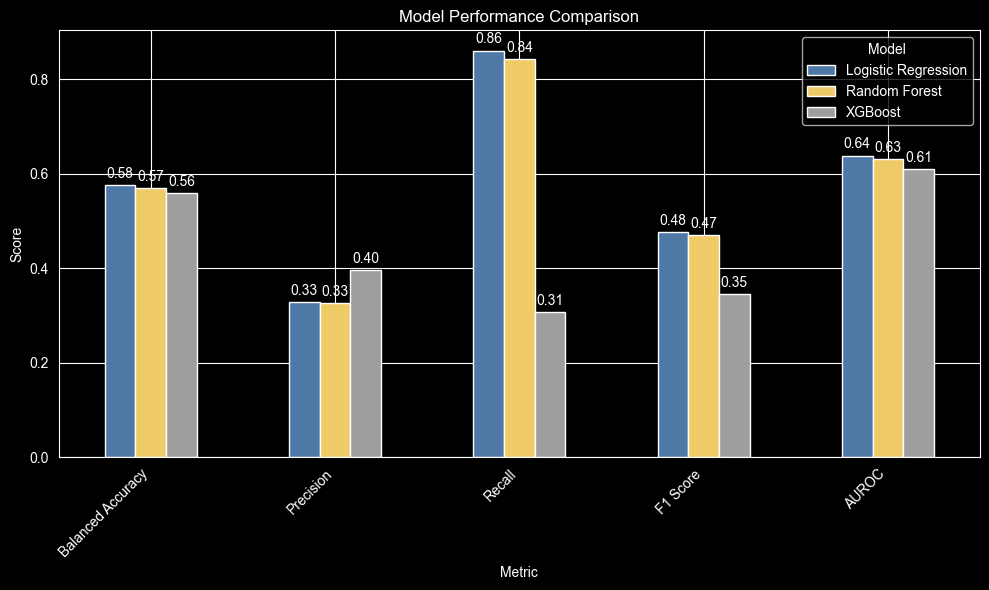

In [46]:
model_comparison(model_comparison_df)

From our evaluation it can be determined that the Logistic Regression model is better for identifying participants with sleep disorder because it achieved slightly higher recall than Random Forest and much higher recall than XGBoost. This means it was more effective at detecting the positive class, which is important given that sleep disorder is the outcome of interest. However given the model’s low precision score, it incorrectly classified many participants without sleep disorder as having sleep disorder.

The model can be used for identifying possible risk patterns, but it should not be interpreted as a highly accurate diagnostic tool.

In [47]:
# Visualize model evaluation results

def plot_model_evaluation(y_test, logreg_pred, logreg_proba, rf_pred, rf_proba,
    xgb_pred, xgb_proba):
    """
    Plot confusion matrices and ROC curves for both supervised learning models.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Confusion Matrices
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        logreg_pred,
        display_labels=["No Sleep Disorder", "Sleep Disorder"],
        ax=axes[0],
        colorbar=False
    )
    axes[0].set_title("Logistic Regression")

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        rf_pred,
        display_labels=["No Sleep Disorder", "Sleep Disorder"],
        ax=axes[1],
        colorbar=False
    )
    axes[1].set_title("Random Forest")

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        xgb_pred,
        display_labels=["No Sleep Disorder", "Sleep Disorder"],
        ax=axes[2],
        colorbar=False
    )
    axes[2].set_title("XGBoost")

    plt.tight_layout()
    plt.show()

In [48]:
# Generate test set predictions and predicted probabilities for each model
# to evaluate and compare their classification performance

logreg_pred = best_models["Logistic Regression"].predict(X_test)
logreg_proba = best_models["Logistic Regression"].predict_proba(X_test)[:, 1]

rf_pred = best_models["Random Forest"].predict(X_test)
rf_proba = best_models["Random Forest"].predict_proba(X_test)[:, 1]

xgb_pred = best_models["XGBoost"].predict(X_test)
xgb_proba = best_models["XGBoost"].predict_proba(X_test)[:, 1]

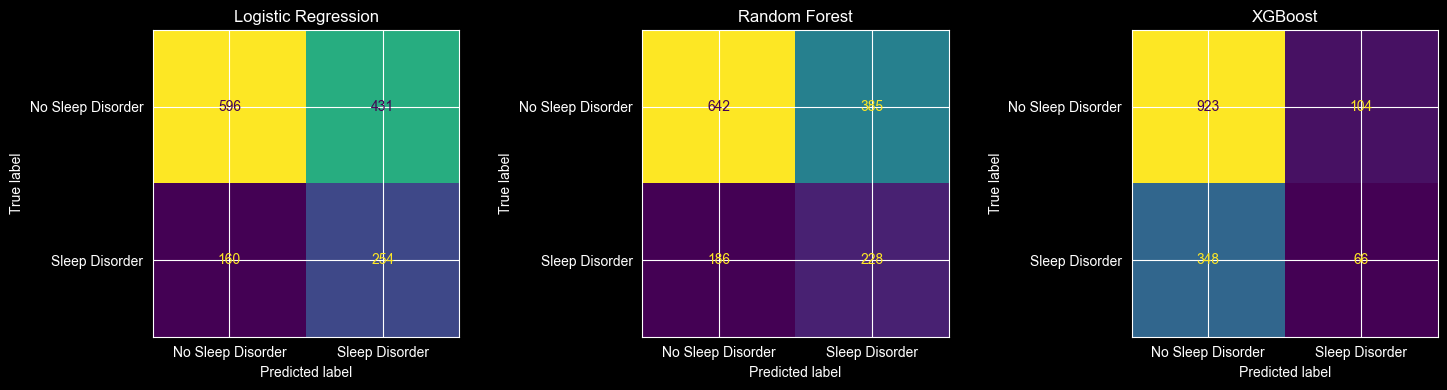

In [49]:
# Call plot_model_evaluation

plot_model_evaluation(
    y_test,
    logreg_pred,
    logreg_proba,
    rf_pred,
    rf_proba,
    xgb_pred,
    xgb_proba
)

Confusion matrices:

* Logistic Regression identified the most participants with sleep disorder and also produced many false positives by classifying participants without sleep disorder as having sleep disorder
* Random Forest identified many participants with sleep disorder, but produced fewer false positives than Logistic Regression. This shows a slightly more balanced pattern of classifying sleep disorder errors
* XGBoost made different types of classification errors, where XGBoost was better at correctly identifying participants without sleep disorder, but missed many true sleep disorder cases

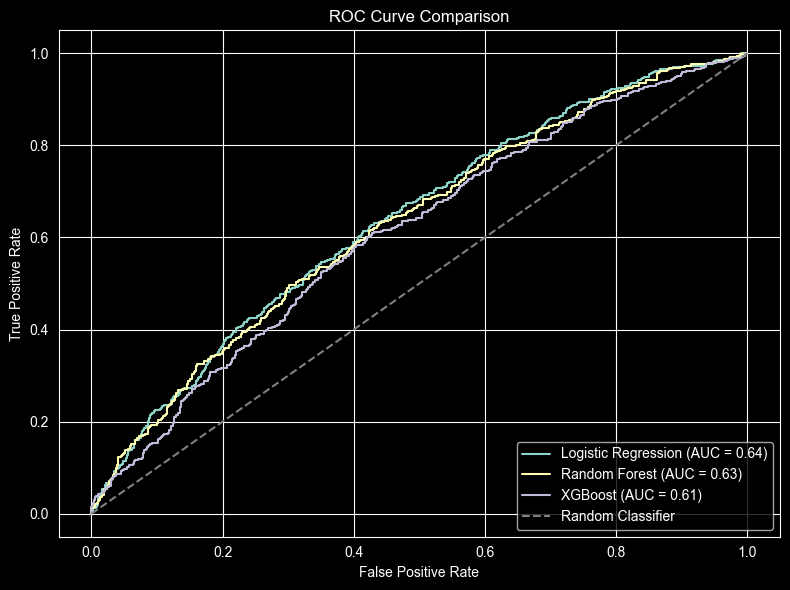

In [50]:
def plot_roc_comparison(y_test, logreg_proba, rf_proba, xgb_proba):
    """
    Plot ROC curves for all supervised learning models on one graph.
    """

    logreg_fpr, logreg_tpr, _ = roc_curve(y_test, logreg_proba)
    rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
    xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

    logreg_auc = roc_auc_score(y_test, logreg_proba)
    rf_auc = roc_auc_score(y_test, rf_proba)
    xgb_auc = roc_auc_score(y_test, xgb_proba)

    plt.figure(figsize=(8, 6))

    plt.plot(logreg_fpr, logreg_tpr, label=f"Logistic Regression (AUC = {logreg_auc:.2f})")
    plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
    plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

plot_roc_comparison(y_test, logreg_proba, rf_proba, xgb_proba)

The ROC comparison shows that Logistic Regression achieved the best overall discrimination between participants with and without sleep disorder, followed closely by Random Forest, while XGBoost performed worst. Since all three curves lie only moderately above the random classifier line, the models demonstrate limited but meaningful predictive ability rather than strong classification performance

### Feature Importance - Logistic Coefficient Analysis

To better understand which predictors were most influential in the best-performing supervised model, we conducted a coefficient analysis using Logistic Regression. Because Logistic Regression achieved the strongest overall performance in our 5-fold cross-validation results, it was selected as the final model for interpretation. In this section, we examine the size of the model coefficients to identify which variables contributed most strongly to the prediction of sleep disorder, with larger absolute coefficients indicating greater influence on the model’s classification.

In [51]:
# Rank top features that influence/hold the most weight in Logistic Regression

def important_features(model, X, top_n=15):
    """
    Rank coefficients from fitted logistic regression model
    """
    classifier = model.named_steps["classifier"]

    feature_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": classifier.coef_[0],
        "AbsCoefficient": np.abs(classifier.coef_[0])
    })

    feature_df = feature_df.sort_values(
        by="AbsCoefficient",
        ascending=False
    ).reset_index(drop=True)

    if_df = feature_df.head(top_n)

    return if_df

In [52]:
# Plot important_features

def plot_coefficients(if_df, model_title, top_n=10):
    """
    Plot top logistic regression coefficients as a horizontal lollipop chart.

    Positive coefficients are shown in blue.
    Negative coefficients are shown in yellow.
    """

    # Select the top features and sort so they plot nicely from bottom to top
    top_features = if_df.head(top_n).sort_values(by="Coefficient")

    # Assign colors by coefficient direction:
    # blue for positive, maize for negative
    colors = [
        "#4E79A7" if coef > 0 else "#EFCB68"
        for coef in top_features["Coefficient"]
    ]

    plt.figure(figsize=(15, 6))
    plt.hlines(
        y=top_features["Feature"],
        xmin=0,
        xmax=top_features["Coefficient"],
        color=colors,
        linewidth=2
    )

    plt.scatter(
        top_features["Coefficient"],
        top_features["Feature"],
        color=colors,
        s=90
    )

    # coefficient labels
    for i, value in enumerate(top_features["Coefficient"]):
        if value >= 0:
            plt.text(
                x=value + 0.003,
                y=i,
                s=f"{value:.3f}",
                va="center",
                fontsize=9
            )
        else:
            plt.text(
                x=value - 0.005,
                y=i,
                s=f"{value:.3f}",
                va="center",
                ha="right",
                fontsize=9
            )

    plt.axvline(x=0, color="#9E9E9E", linestyle="--")

    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(model_title)
    plt.tight_layout()
    plt.show()

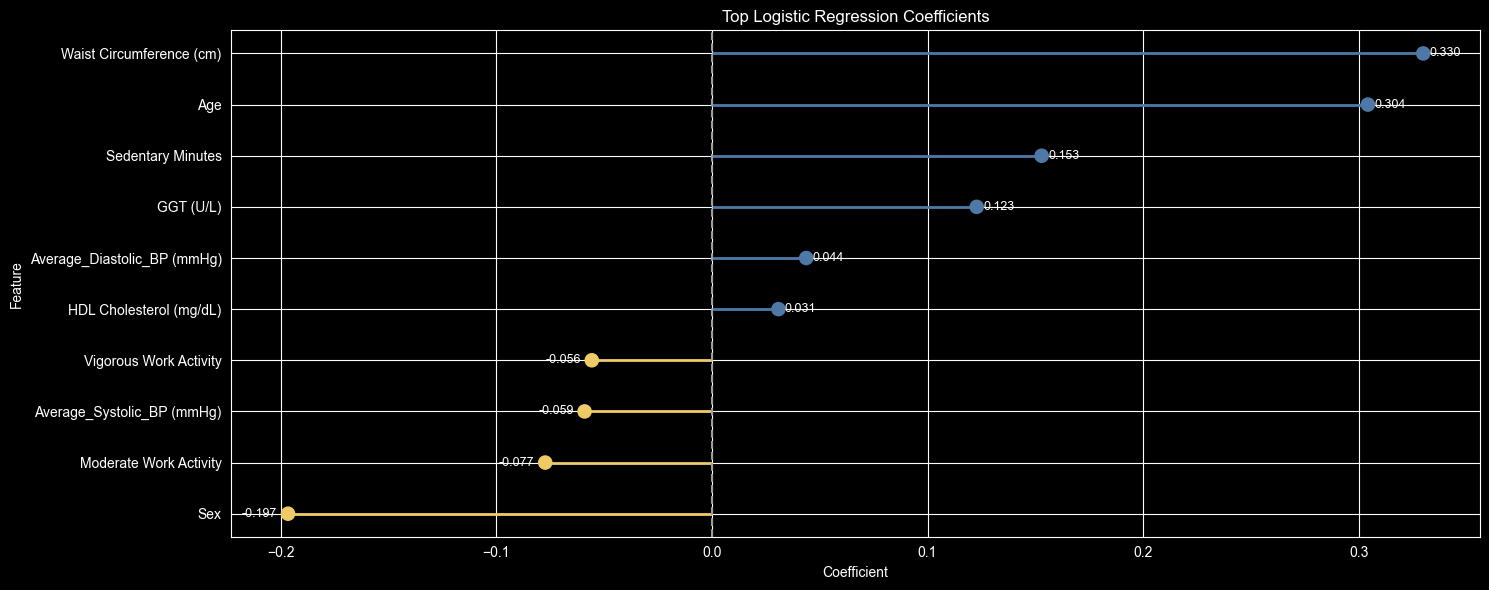

In [53]:
# Call plot_coefficients

coef_df = important_features(
    best_models["Logistic Regression"],
    X_train,
    top_n=15
)

plot_coefficients(
    if_df=coef_df,
    model_title="Top Logistic Regression Coefficients",
    top_n=10
)

One important note about this chart is that the features on the right are associated with a higher likelihood of sleep disorder, while features on the left are associated with a lower likelihood in the model.

As seen above, the most important predictors are:

1. Waist Circumference
2. Age
3. Sex
4. Sedentary Minutes
5. GGT

This suggests that the model relied most heavily on body composition, age, sex, sedentary behavior, and metabolic health when classifying whether someone had a sleep disorder. The strongest feature was waist circumference, followed by age and sex. This means that body size and demographic differences are especially influential in the model. This makes sense as sleep problems are often connected with broader cardiometabolic health patterns. Sedentary minutes was also important, which suggests that lower activity levels or more sedentary behavior may help distinguish participants with and without sleep disorder in the model. Since GGT is a biomarker related to liver and metabolic function, its importance suggests that broader metabolic health patterns may also help distinguish participants with and without sleep disorder in the model.

### Abalation Analysis

In [54]:
# Run ablation analysis to see how model performance changes
# when selected features are removed

def ablation_analysis(X, y, phenotype_col=None, cv=5):
    """
    Evaluate how model performance changes when selected features
    are removed from Logistic Regression

    Parameters:
    - X: feature dataframe
    - y: target series
    - phenotype_col: phenotype column name, if applicable
    - cv: number of cross-validation folds

    Returns:
    - ablation_df: mean and SD of evaluation metrics dataframe
    """

    # Feature groups
    ablation_sets = {
        "No Ablation": [],
        "Without Top 3 Predictors": [
            "Waist Circumference (cm)",
            "Age",
            "Sex"
        ],
        "Without Activity Features": [
            "Sedentary Minutes",
            "Moderate Work Activity",
            "Vigorous Work Activity"
        ],
        "Without Biomarker Features": [
            "GGT (U/L)",
            "HDL Cholesterol (mg/dL)"
        ]
    }

    # Add phenotype ablation only if the column exists
    if phenotype_col is not None and phenotype_col in X.columns:
        ablation_sets["Without Phenotype"] = [phenotype_col]

    # Cross-validation setup
    skf = StratifiedKFold(
        n_splits=cv,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scoring = {
        "f1": "f1",
        "precision": "precision",
        "recall": "recall",
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc"
    }

    rows = []

    for ablation_name, remove_features in ablation_sets.items():
        valid_remove_features = [
            col for col in remove_features if col in X.columns
        ]

        # Ablated dataset
        X_ablated = X.drop(columns=valid_remove_features, errors="ignore")
        preprocessor_ablation, _, _ = preprocessor_pipeline(X_ablated)

        logreg_model = Pipeline(steps=[
            ("preprocessor", preprocessor_ablation),
            ("classifier", LogisticRegression(
                random_state=RANDOM_STATE,
                max_iter=2000
            ))
        ])

        # Run cross-validation
        scores = cross_validate(
            logreg_model,
            X_ablated,
            y,
            cv=skf,
            scoring=scoring,
            n_jobs=-1
        )

        rows.append({
            "Ablation": ablation_name,
            "Removed Features": ", ".join(valid_remove_features) if valid_remove_features else "None",
            "F1 Mean": scores["test_f1"].mean(),
            "F1 SD": scores["test_f1"].std(),
            "Precision Mean": scores["test_precision"].mean(),
            "Recall Mean": scores["test_recall"].mean(),
            "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
            "AUROC Mean": scores["test_roc_auc"].mean()
        })

    ablation_df = pd.DataFrame(rows).round(3)

    return ablation_df

In [55]:
# Call ablation_analysis

ablation_df = ablation_analysis(
    X=X_train,
    y=y_train,
    phenotype_col=None,
    cv=5
)

ablation_df

,Ablation,Removed Features,F1 Mean,F1 SD,Precision Mean,Recall Mean,Balanced Accuracy Mean,AUROC Mean
0,No Ablation,None,0.129,0.013,0.507,0.075,0.521,0.651
1,Without Top 3 Predictors,"Waist Circumference (cm), Age, Sex",0.105,0.026,0.500,0.059,0.517,0.619
2,Without Activity Features,"Sedentary Minutes, Moderate Work Activity, Vig...",0.090,0.015,0.462,0.050,0.512,0.643
3,Without Biomarker Features,"GGT (U/L), HDL Cholesterol (mg/dL)",0.102,0.014,0.475,0.058,0.514,0.647


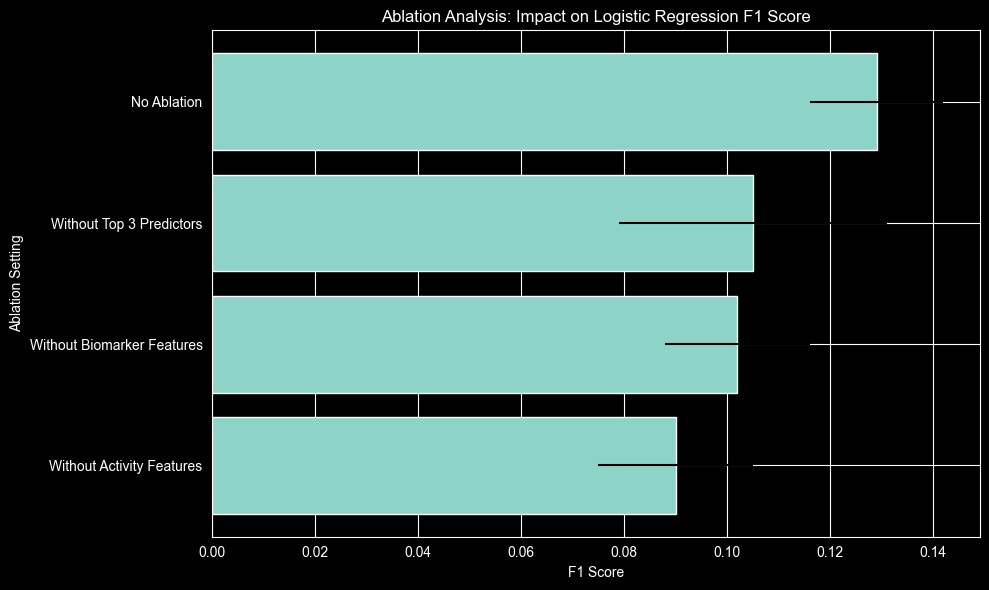

In [56]:
# Plot ablation_analysis

def plot_ablation_f1(ablation_df):
    """
    Plot F1 mean across ablation settings
    """
    plot_df = ablation_df.sort_values(by="F1 Mean", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["Ablation"], plot_df["F1 Mean"], xerr=plot_df["F1 SD"])
    plt.xlabel("F1 Score")
    plt.ylabel("Ablation Setting")
    plt.title("Ablation Analysis: Impact on Logistic Regression F1 Score")
    plt.tight_layout()
    plt.show()

plot_ablation_f1(ablation_df)

We can see here that the logistic regression model performance relied on all features, as we dropped the top 3 features the model performed worst. We also noticed that the model relies on a combination of demographic, activity, and biomarker features, rather than on only one small set of predictors.

One thing to note is that after removing the activity-related variables, it caused the largest drop in F1 score. This may suggest that these features contributed the most to the model’s predictive ability. Removing the top three predictors and biomarker related features also reduced performance, which could suggest that these variables still provide useful information.

### Threshold Sensitivity Analysis

In [57]:
# Test different classification thresholds for Logistic Regression
# to examine the tradeoff between precision, recall, and overall performance

def threshold_sensitivity_analysis(model, X_test, y_test, thresholds=None):
    """
    Evaluate Logistic Regression performance across different
    classification thresholds

    Parameters:
    - model: fitted Logistic Regression pipeline
    - X_test: test feature dataframe
    - y_test: true test labels
    - thresholds: list or array of thresholds to evaluate

    Returns:
    - threshold_df: dataframe of metrics across thresholds
    """

    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    # Find predicted probabilities for the positive class
    y_proba = model.predict_proba(X_test)[:, 1]

    rows = []

    for threshold in thresholds:
        y_pred_thresh = (y_proba >= threshold).astype(int)

        rows.append({
            "Threshold": round(threshold, 2),
            "Precision": precision_score(y_test, y_pred_thresh, zero_division=0),
            "Recall": recall_score(y_test, y_pred_thresh, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred_thresh, zero_division=0),
            "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_thresh)
        })

    threshold_df = pd.DataFrame(rows).round(3)

    return threshold_df

In [58]:
# Call threshold_sensitivity_analysis

threshold_df = threshold_sensitivity_analysis(
    model=best_models["Logistic Regression"],
    X_test=X_test,
    y_test=y_test
)

threshold_df

,Threshold,Precision,Recall,F1 Score,Balanced Accuracy
0,0.10,0.287,1.000,0.446,0.500
1,0.15,0.287,1.000,0.446,0.500
2,0.20,0.289,1.000,0.448,0.504
3,0.25,0.293,0.986,0.452,0.514
4,0.30,0.303,0.971,0.462,0.535
5,0.35,0.314,0.932,0.469,0.555
6,0.40,0.329,0.860,0.476,0.576
7,0.45,0.345,0.739,0.471,0.587
8,0.50,0.371,0.614,0.462,0.597
9,0.55,0.402,0.466,0.432,0.593


There is a clear tradeoff between precision and recall in the logistic regression model where the lower thresholds recall was very high but precision was low. This could indicate that the model identified more sleep disorder cases but also produced more false positives. We noticed that as the threshold increased, precision improved while recall dropped sharply.

Ultimatley, we found that the thresholds around 0.40 to 0.50 provided the best overall balance for this project.

### Failure Analysis

To examine specific test cases where the final Logistic Regression model made incorrect predictions, we will look at the types of errors the model makes and try to identify possible reasons for those mistakes.

In [59]:
# Review misclassified test cases from the final Logistic Regression model
# to understand the types of errors the model is making

def failure_analysis(model, X_test, y_test, top_n=3):
    """
    Identify misclassified test cases and summarize likely failure types

    Parameters:
    - model: fitted Logistic Regression pipeline
    - X_test: test feature dataframe
    - y_test: true test labels
    - top_n: number of false positives and false negatives to display

    Returns:
    - false_positives_df: top false positive cases
    - false_negatives_df: top false negative cases
    - failures_df: all misclassified cases
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Results dataframe
    failures_df = X_test.copy()
    failures_df["Actual"] = y_test.values
    failures_df["Predicted"] = y_pred
    failures_df["Predicted_Probability"] = y_proba
    failures_df = failures_df[failures_df["Actual"] != failures_df["Predicted"]].copy()

    # False positives: predicted 1, actual 0
    false_positives_df = failures_df[
        (failures_df["Actual"] == 0) & (failures_df["Predicted"] == 1)
    ].sort_values(by="Predicted_Probability", ascending=False)

    # False negatives: predicted 0, actual 1
    false_negatives_df = failures_df[
        (failures_df["Actual"] == 1) & (failures_df["Predicted"] == 0)
    ].sort_values(by="Predicted_Probability", ascending=True)

    return (
        false_positives_df.head(top_n),
        false_negatives_df.head(top_n),
        failures_df
    )

In [60]:
# Call failure_analysis

false_positives_df, false_negatives_df, failures_df = failure_analysis(
    model=best_models["Logistic Regression"],
    X_test=X_test,
    y_test=y_test,
    top_n=3
)

false_positives_df

,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),HDL Cholesterol (mg/dL),Total Cholesterol (mg/dL),HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),Actual,Predicted,Predicted_Probability
1687,75,0.0,43.7,144.3,2.0,2.0,2.0,900.0,6.7,35.0,210.0,8.20,7.4,16.0,23.0,110.666667,64.000000,0,1,0.839823
5509,80,0.0,35.6,107.1,1.0,1.0,1.0,1020.0,5.4,58.0,154.0,1.74,4.3,9.0,8.0,137.666667,93.333333,0,1,0.814628
2437,49,0.0,42.3,131.4,2.0,1.0,2.0,540.0,6.2,44.0,154.0,13.20,6.8,70.0,140.0,162.333333,113.000000,0,1,0.798834


False positive 1:

1687: The model likely predicted sleep disorder because this participant had a very strong high-risk metabolic profile despite the true label being no sleep disorder.

5509: The model likely classified this participant as having sleep disorder because older age, high sedentary time, and elevated body composition measures made them resemble the positive class.

2437: The model likely overpredicted here because multiple cardiometabolic risk indicators were elevated, making this case look similar to participants with sleep disorder.

In [61]:
false_negatives_df

,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),HDL Cholesterol (mg/dL),Total Cholesterol (mg/dL),HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),Actual,Predicted,Predicted_Probability
4334,23,1.0,19.6,70.2,1.0,1.0,2.0,30.0,5.6,49.0,110.0,1.06,6.0,10.0,17.0,117.333333,74.666667,1,0,0.206635
928,22,1.0,21.3,72.8,2.0,2.0,2.0,360.0,5.4,66.0,152.0,0.67,7.1,35.0,33.0,113.000000,66.000000,1,0,0.210870
3378,22,1.0,19.3,75.7,2.0,2.0,1.0,420.0,5.3,46.0,239.0,0.42,6.1,11.0,15.0,109.000000,67.333333,1,0,0.213150


4334: The model likely missed this case because the participant was young and had a relatively low-risk profile on the key features the model relied on.

928: The model likely predicted no sleep disorder because this participant appeared metabolically healthier than typical positive cases.

3378: The model likely failed on this record because the participant’s features did not show the stronger risk patterns the model associated with sleep disorder.

Overall, the model is mostly making three kinds of mistakes:
1. Flags people as having a sleep disorder when they have a strong cardiometabolic risk profile
2. Misses true sleep disorder cases when the person looks relatively healthy on the variables the model uses most
3. Unusually large biomarker values produced a large positive linear combination

The model is leaning heavily on patterns like body size, sedentary behavior, inflammation, and metabolic markers, so when a real case doesn'tt match this pattern, the model misses it

## Unsupervised Learning

The unsupervised section compares k-means clustering to hierarchical clustering. For k-means an elbow and silhouette plot evaluate values of k from 3 to 10. The optimal k is then used to fit the best k-means model. This is then evaluated for initialization stability and data stability. A hierarchical clustering approach is next taken using a dendrogram and silhouette plot to evaluate the optimal k. The data stability is also tested for the hierarchical approach.

The optimal model is selected as k-means as a result of a slightly higher silhouette score and higher ARI score (data stabilit). K-means is then used to create phenotypes which are summarized and visualized.

#### Prepare Data for Clustering







In [62]:
# Our cluster variables will be the mec features

# Exclude the ID column
no_id = [col for col in mec_features if col != "ID"]
X_cluster = cardio_met[no_id]

# Scale before clustering to standardize
scaler = StandardScaler()
scaled = scaler.fit_transform(X_cluster)

#### K-Means Clustering

In [63]:
# Create elbow plot for different k cluster values

inert = []

# Try a range of k values
for k in range (3,10):

  mod = KMeans(n_clusters=k, random_state=42,n_init=20)
  mod.fit(scaled)
  inert.append(mod.inertia_)

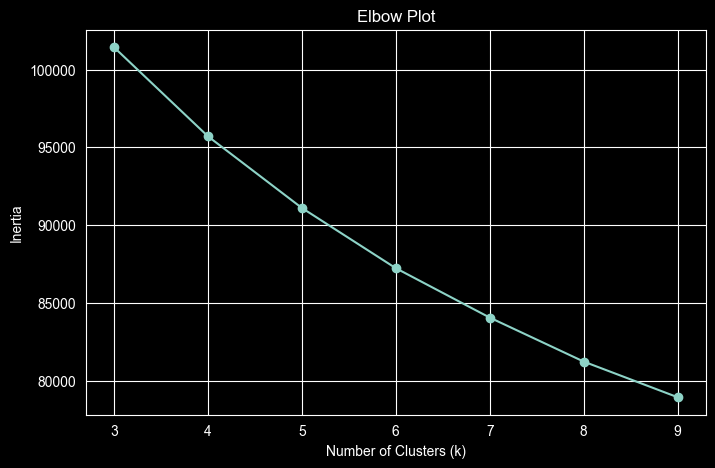

In [64]:
# Elbow plot for k values
plt.figure(figsize=(8,5))
plt.plot(range(3,10), inert, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot')

plt.grid(True)
plt.show()

In [65]:
# Silhouette Scores

scores = []

# for k values between 2 and 20
for k in range (3,10):

  mod = KMeans(n_clusters=k, random_state=42, n_init=20)
  labels = mod.fit_predict(scaled)
  scores.append(silhouette_score(scaled, labels))

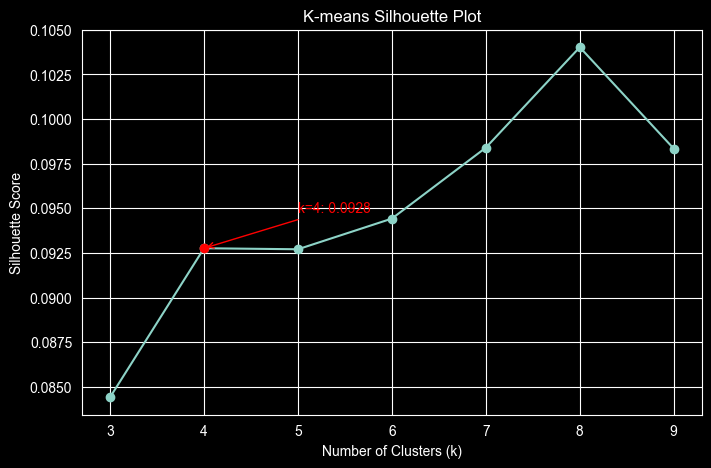

In [66]:
# K-means silhouette plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(3, 10), scores, marker='o')

# We chose k=4
k_label = 4
sil_score = scores[k_label - 3]

# Label the k we chose
ax.annotate(f'k=4: {sil_score:.4f}',
            xy=(k_label, sil_score),
            xytext=(k_label + 1, sil_score + 0.002),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)
ax.scatter([k_label], [sil_score], color='red', zorder=5)

ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('K-means Silhouette Plot')
ax.grid(True)
plt.show()

In [67]:
# Set k value and fit final model
k = 4
mod = KMeans(n_clusters=k, random_state=42)

# Create phenotype feature
cardio_met["Phenotype"] = mod.fit_predict(scaled)

#### Test Cluster Stability

In [68]:
# Test cluster initialization stability by comparing two datasets
# (resampled from original) and creating two k-means models each
# with k clusters but with different initializations

# this tests initialization sability

# Across 100 iterations
n_its = 100
ari_scores = []

for i in range(n_its):
    # create fake dataset
    X_boot = resample(scaled, replace=True, random_state=i)

    # Fit model a
    mod_a = KMeans(n_clusters=k, random_state=i, n_init=20)
    labels_a = mod_a.fit_predict(X_boot)

    # Fit model b
    mod_b = KMeans(n_clusters=k, random_state=i+1000, n_init=20)
    labels_b = mod_b.fit_predict(X_boot)

    # Compare model a and b labels
    ari = adjusted_rand_score(labels_a, labels_b)
    ari_scores.append(ari)

mean_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)

print(f"Mean ARI: {mean_ari:.3f} ± {std_ari:.3f}")

Mean ARI: 0.972 ± 0.031


In [69]:
# Test data stability
# Take a random subset of 80% of the data, see if resulting cluster
# memberships are the same

# Run 100 iterations
n_its = 100
ari_scores = []

# Original labels
labels = cardio_met["Phenotype"].values

for i in range(n_its):
  # Sample 80% of the original data
  idx = np.random.choice(len(scaled), size=int(0.8 * len(scaled)), replace=False)
  X_sub = scaled[idx]

  # Fit new model ONLY on subset
  s_mod = KMeans(n_clusters=k, random_state=i, n_init=20)
  sub_labels = s_mod.fit_predict(X_sub)

  # Compare subset and original labels of those in the subset
  ari = adjusted_rand_score(labels[idx], sub_labels)
  ari_scores.append(ari)

mean_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)

print(f"Mean ARI: {mean_ari:.3f} ± {std_ari:.3f}")

Mean ARI: 0.905 ± 0.040


### Hierarchical Clustering

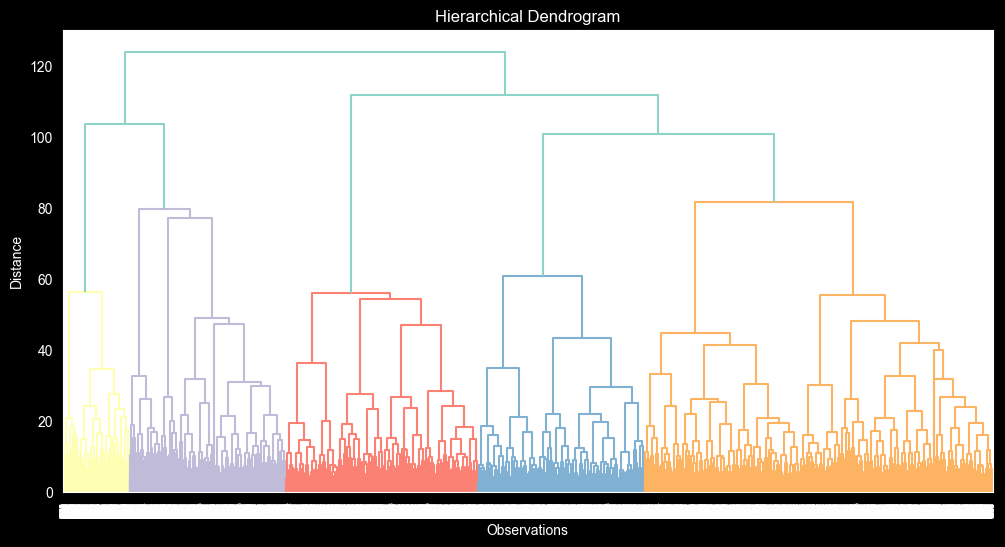

In [70]:
# Hierarchical clustering
Z = linkage(scaled, method='ward')
plt.figure(figsize=(12,6))
dendrogram(Z, color_threshold=90)
plt.title("Hierarchical Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

In [71]:
# Silhouette scores for hierarchical clustering
scores_h = []
for k in range(3,10):
  mod = AgglomerativeClustering(n_clusters=k, linkage='ward')
  labels = mod.fit_predict(scaled)
  scores_h.append(silhouette_score(scaled, labels))

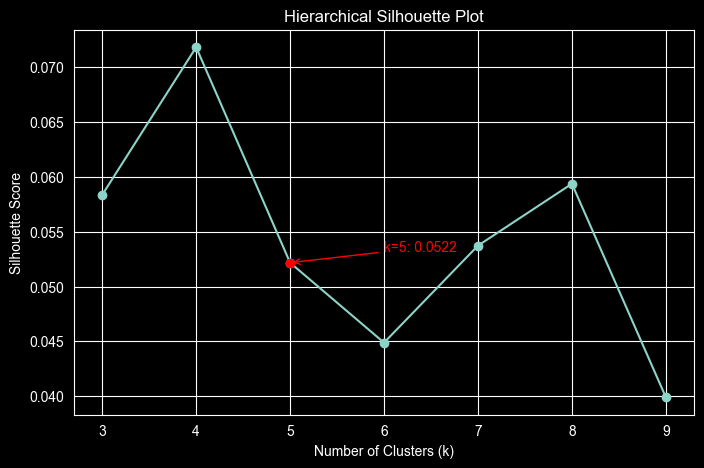

In [72]:
# Plot the silhouette score and label of k to be used
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(3, 10), scores_h, marker='o')

# We chose k=5
k_label = 5
sil_score = scores_h[k_label - 3]

ax.annotate(f'k=5: {sil_score:.4f}',
            xy=(k_label, sil_score),
            xytext=(k_label + 1, sil_score + 0.001),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

ax.scatter([k_label], [sil_score], color='red', zorder=5)

ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Hierarchical Silhouette Plot')
ax.grid(True)
plt.show()

In [73]:
# Final hierarchical model
k= 5
hier_mod = AgglomerativeClustering(n_clusters=k, linkage='ward')

# Create hierarchical phenotype labels
cardio_met["Phenotype_H"] = hier_mod.fit_predict(scaled)

# Examine cluster size
cardio_met["Phenotype_H"].value_counts()

Phenotype_H
0    2695
2    1490
4    1289
1    1211
3     522
Name: count, dtype: int64

In [74]:
summary_hier = (cardio_met.groupby("Phenotype_H").mean(numeric_only=True))
summary_hier = summary_hier[no_id]
summary_hier

,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),HDL Cholesterol (mg/dL),Total Cholesterol (mg/dL),HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg)
Phenotype_H,,,,,,,,,,,,,,,,,
0,59.186642,0.487941,28.256387,98.737477,1.939147,1.640074,1.834508,334.831169,5.762078,56.451577,191.247124,2.676575,5.371688,19.096475,25.290538,131.530427,76.162090
1,53.438481,0.371594,37.605509,118.543683,1.867878,1.681255,1.850537,384.146986,6.799092,47.154418,180.886870,8.631113,5.698183,20.627581,30.930239,124.511836,75.977567
2,43.341611,0.663087,29.865530,100.352617,1.048322,1.159060,1.684564,267.946309,5.580604,50.218121,179.077852,3.015336,5.506846,21.310738,25.203356,120.910738,73.674720
3,46.43295,0.693487,30.649080,103.789272,1.766284,1.576628,1.756705,327.814176,5.738889,49.831418,195.921456,3.485958,6.068199,53.348659,95.039464,126.485632,78.510536
4,32.416602,0.363072,25.212568,86.341971,1.996897,1.698216,1.640031,375.155935,5.277657,56.429015,175.419705,2.120760,4.733592,15.853375,17.354538,109.648694,67.703388


In [75]:
# Check overlap between phenotypes created by k-means and hierarchical models
ari_between = adjusted_rand_score(cardio_met["Phenotype_H"], cardio_met["Phenotype"])
ari_between

0.29282241201093695

In [76]:
# Test data stability for the hierarchical model
# Take a random subset of 80% of the data, see if resulting cluster
# memberships are the same

n_its = 100
ari_scores = []
labels = cardio_met["Phenotype_H"].values

for i in range(n_its):
  idx = np.random.choice(len(scaled), size=int(0.8 * len(scaled)), replace=False)

  X_sub = scaled[idx]

  # Fit new model only on subset
  s_mod = AgglomerativeClustering(n_clusters=5, linkage='ward')
  sub_labels = s_mod.fit_predict(X_sub)

  # Compare subset and original labels
  ari = adjusted_rand_score(labels[idx], sub_labels)
  ari_scores.append(ari)


print(f"Mean ARI: {np.mean(ari_scores):.3f} ± {np.std(ari_scores):.3f}")

Mean ARI: 0.248 ± 0.076


#### Cluster Profile Summary

Hierarchical clustering performs worse than k-means in terms of data stability and silhouette scores. The final clustering model to create phenotypes will use k-means.

In [77]:
# Cluster summaries for final phenotypes
summary = cardio_met.groupby("Phenotype").mean(numeric_only=True)
summary = summary[no_id]

summary


,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),HDL Cholesterol (mg/dL),Total Cholesterol (mg/dL),HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg)
Phenotype,,,,,,,,,,,,,,,,,
0,64.576279,0.449072,27.573789,97.652196,1.907198,1.732911,1.796741,325.081485,5.959756,58.186962,194.590312,2.586806,5.304844,17.675871,24.485740,137.019617,76.778708
1,35.038121,0.378546,25.296809,86.876020,1.695035,1.481826,1.709220,317.091755,5.325887,56.919770,172.898936,2.189227,4.613564,16.264184,17.887979,110.230940,67.465056
2,46.024306,0.904861,31.405992,106.792431,1.503472,1.366667,1.711806,325.252083,5.831528,45.350694,195.281250,3.020995,6.397500,38.436111,57.947639,127.953356,80.198958
3,51.347158,0.333333,39.542218,122.246544,1.800307,1.579109,1.870968,399.139785,6.373656,46.516129,175.547619,8.992663,5.770046,19.504608,28.616928,120.712622,75.269841


In [78]:
# Examine cluster sizes
cardio_met["Phenotype"].value_counts()

Phenotype
1    2256
0    2209
2    1440
3    1302
Name: count, dtype: int64

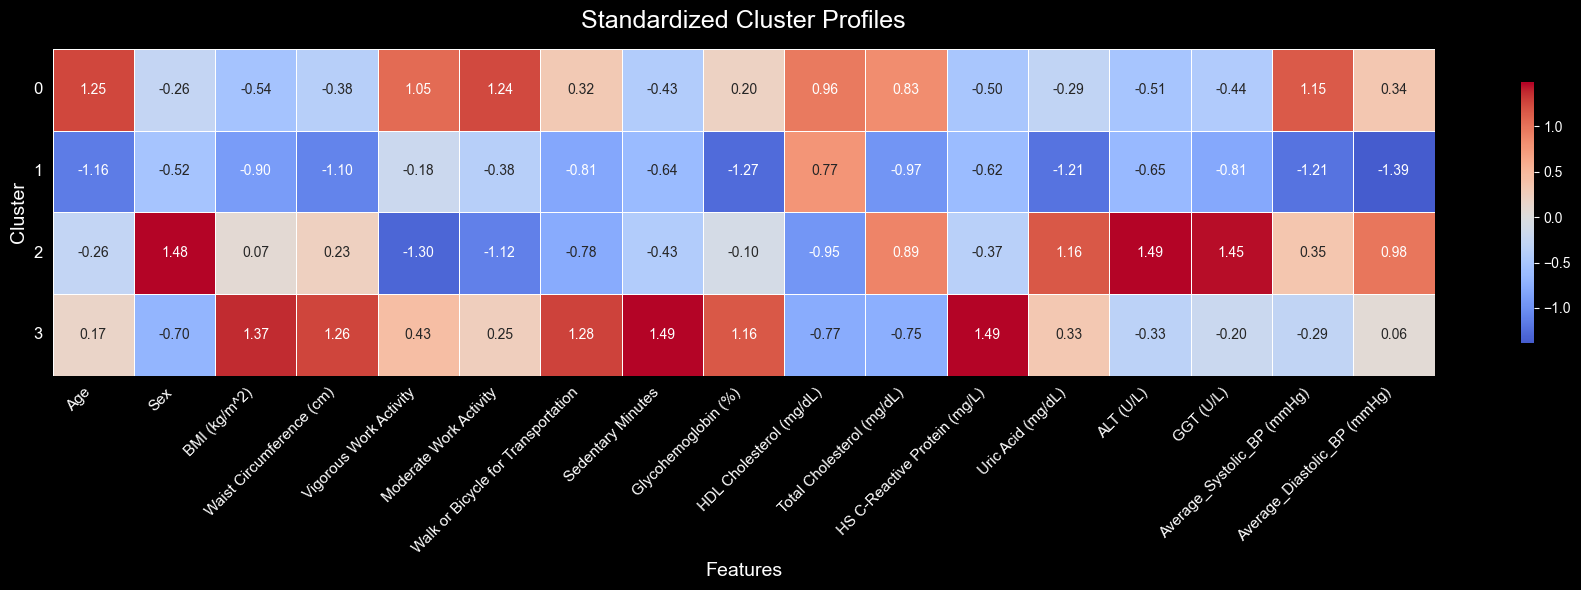

In [79]:
# Create a scaled heat map to visualize cluster characteristics

# Standardize cluster profiles
cluster_scaled = (summary - summary.mean()) / summary.std()
cluster_scaled = cluster_scaled.astype(float)

plt.figure(figsize=(18, 6))
ax = sns.heatmap(
    cluster_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size":10},
    cbar_kws={"shrink":0.8}
)

ax.set_title("Standardized Cluster Profiles", fontsize=18, pad=15)

ax.set_xlabel("Features", fontsize=14)
ax.set_ylabel("Cluster", fontsize=14)

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

#### PCA Visualization

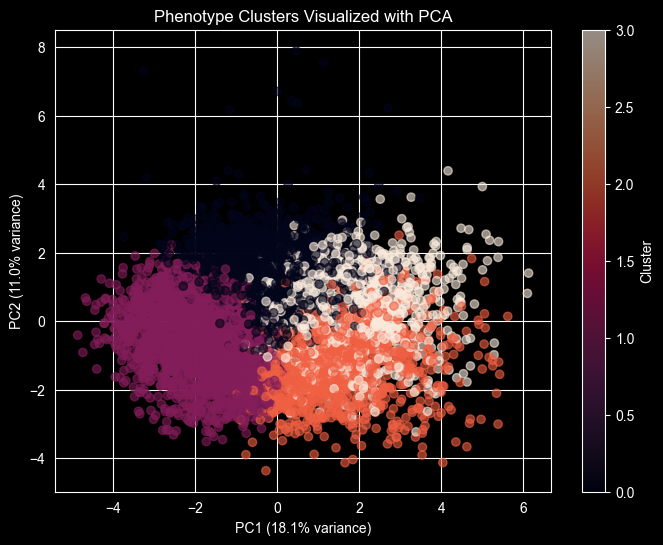

In [80]:
# Visualize clusters using pca to evaluate: Do the clusters separate in a
# meaningful way in the largest directions of variation?

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled)
plt.figure(figsize=(8,6))

# Color represents the phenotype group
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cardio_met["Phenotype"],
    alpha=0.6
)

# Label pc1 and pc2 with their percent variance explained
plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)"
)

plt.title("Phenotype Clusters Visualized with PCA")
plt.colorbar(label="Cluster")
plt.show()

/Users/yasthilsingh/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


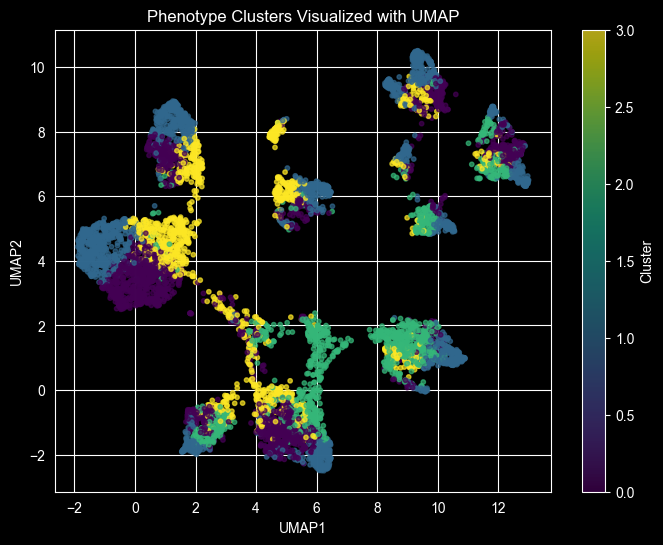

In [81]:
# Create a UMAP visualization
# UMPA preserves local structure, so, points that are close to eachother in
# the high dimensional space of our cluster components will be close together
# in this 2D projection.

umap = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap.fit_transform(scaled)

plt.figure(figsize=(8,6))

# Colors represent the phenotypes
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=cardio_met["Phenotype"],
    cmap="viridis",
    alpha=0.7,
    s=10
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Phenotype Clusters Visualized with UMAP")
plt.colorbar(label="Cluster")
plt.show()

#### Lifestyle Phenotype Interpretations

**Phenotype 0 (Age / BP driven risk)**: This group has the highest average age at about 64.6 years. The average systolic BP is the highest among groups but the group has a moderate average diastolic BP. This group has relatively low sedentary minutes and the least amount of vigorous and moderate work activity.

**Phenotype 1 (Good cardiometabolic health, young)**: This is the youngest group with an average age of 35.0 years. This group also has the lowest BMI and waist circumference on average. The average blood pressures are healthy and this group has the lowest average glycohemoglobin, HS-CRP, and total cholesterol.

**Phenotype 2 (Metabolic/ Liver Risk):** Middle aged with average of 46.0, 90% male, BMI 31.4 (Class 1 obesity), waist circumference 107 cm. ALT and GGT are both clearly the highest on average in this phenotype, suggesting hepatic involvement. This group also has the highest amount of moderate and vigorous work intensity across groups (survey answers encoded 1 for yes, work involved moderate/vigorous work and 2 for no).

**Phenotype 3 (Obese, cardiometabolic risk):** This group is late-middle aged with an average age of 51.3 years. This group has the highest average BMI and sedentary minutes, and lowest work activity. This group has an extremely high HS-CRP of around 8.99 while other groups all have levels around 2-3. The glycohemoglobin is also significantly higher than the other groups at 6.37 on average, close to the levels of those with type 2 diabetes which is 6.5%.

## Supervised Model with Phenotype Feature

We will now evaluates whether adding the phenotype variable improves supervised learning performance. The phenotype model will use the top predictors from the Random Forest model along with the phenotype label derived from clustering.

### Feature Selection

In [82]:
# Supervised learning with phenotype feature

phenotype_col = "Phenotype"
target_col = "SLQ050"

# Supervised dataframe
sl_pheno_df = cardio_met.copy()

sleep_outcome = master_df[["SEQN", target_col]].copy()
sleep_outcome = sleep_outcome.rename(columns={"SEQN": "ID"})

sl_pheno_df = sl_pheno_df.merge(
    sleep_outcome,
    on="ID",
    how="inner"
)

# Sleep Disorder
sl_pheno_df = sl_pheno_df[sl_pheno_df[target_col].isin([1, 2])
].copy()
sl_pheno_df[target_col] = sl_pheno_df[target_col].map({
    1: 1,  # Sleep disorder
    2: 0   # No sleep disorder
})

# Supervised features + phenotype
sl_phenotype_features = sl_features.copy()
if phenotype_col not in sl_phenotype_features:
    sl_phenotype_features.append(phenotype_col)

# Phenotype (categorical)
sl_pheno_df[phenotype_col] = sl_pheno_df[phenotype_col].astype("category")

X_phenotype = sl_pheno_df[sl_phenotype_features]
y_phenotype = sl_pheno_df[target_col]

In [83]:
print("Dataset Summary With Phenotype:")
print(f"Observations: {len(sl_pheno_df):,}")
print(f"Predictors: {len(sl_phenotype_features)}")

print(f"\nX shape: {X_phenotype.shape}")
print(f"y shape: {y_phenotype.shape}")

Dataset Summary With Phenotype:
Observations: 7,204
Predictors: 18

X shape: (7204, 18)
y shape: (7204,)


### Model Training

In [84]:
# Train/test split for phenotype model

X_train_phenotype, X_test_phenotype, y_train_phenotype, y_test_phenotype = (
test_train_split(
    X_phenotype,
    y_phenotype
  )
)

### Preprocessing and Run Model

In [85]:
# Call preprocessor function

(preprocessor_phenotype,
    numeric_features_phenotype,
    categorical_features_phenotype
) = preprocessor_pipeline(X_phenotype)

models_phenotype = supervisedlearning_models(preprocessor_phenotype)

### Hyperparameter Analysis

Utilizing the best estimators, we will run the gridsearch model.

Please note, this cell will take somwhere around **9 minutes** to run as it is running through both models, multiple parameter combinations and cross validation folds.

In [86]:
# Call gridsearch_models function

best_models_phenotype, phenotype_results_df = gridsearch_models(
    models=models_phenotype,
    X_train=X_train_phenotype,
    y_train=y_train_phenotype,
    cv=5,
    scoring="f1"
)

phenotype_results_df

,Model,Best CV F1,Best Parameters
0,Logistic Regression,0.475,"{'classifier__C': 0.1, 'classifier__class_weig..."
1,Random Forest,0.465,"{'classifier__class_weight': 'balanced', 'clas..."
2,XGBoost,0.251,"{'classifier__colsample_bytree': 1.0, 'classif..."


In [87]:
# Call crossval_summary

phenotype_cv_summary_df = crossval_summary(
    models=best_models_phenotype,
    X=X_train_phenotype,
    y=y_train_phenotype,
    cv=5
)

phenotype_cv_summary_df

,Model,F1 Mean,F1 SD,Precision Mean,Precision SD,Recall Mean,Recall SD,Balanced Accuracy Mean,Balanced Accuracy SD,AUROC Mean,AUROC SD
0,Logistic Regression,0.475,0.026,0.385,0.019,0.618,0.039,0.610,0.023,0.651,0.030
1,Random Forest,0.466,0.030,0.393,0.022,0.572,0.050,0.608,0.024,0.644,0.030
2,XGBoost,0.257,0.006,0.410,0.028,0.188,0.007,0.539,0.005,0.597,0.018


### Phenotype Models Evaluation

In [88]:
# Compare models

(
    lr_phenotype_results,
    lr_phenotype_model,
    lr_phenotype_pred,
    lr_phenotype_proba
) = evaluate_model(
    model=best_models_phenotype["Logistic Regression"],
    X_train=X_train_phenotype,
    X_test=X_test_phenotype,
    y_train=y_train_phenotype,
    y_test=y_test_phenotype,
    model_name="Logistic Regression + Phenotype",
    threshold=0.40
)

(
    rf_phenotype_results,
    rf_phenotype_model,
    rf_phenotype_pred,
    rf_phenotype_proba
) = evaluate_model(
    model=best_models_phenotype["Random Forest"],
    X_train=X_train_phenotype,
    X_test=X_test_phenotype,
    y_train=y_train_phenotype,
    y_test=y_test_phenotype,
    model_name="Random Forest + Phenotype",
    threshold=0.40
)

(
    xgb_phenotype_results,
    xgb_phenotype_model,
    xgb_phenotype_pred,
    xgb_phenotype_proba
) = evaluate_model(
    model=best_models_phenotype["XGBoost"],
    X_train=X_train_phenotype,
    X_test=X_test_phenotype,
    y_train=y_train_phenotype,
    y_test=y_test_phenotype,
    model_name="XGBoost + Phenotype",
    threshold=0.40
)

phenotype_model_comparison_df = pd.DataFrame([
    lr_phenotype_results,
    rf_phenotype_results,
    xgb_phenotype_results
]).round(3)

phenotype_model_comparison_df

,Model,Threshold,Balanced Accuracy,Precision,Recall,F1 Score,AUROC
0,Logistic Regression + Phenotype,0.4,0.576,0.329,0.860,0.476,0.638
1,Random Forest + Phenotype,0.4,0.572,0.327,0.848,0.472,0.626
2,XGBoost + Phenotype,0.4,0.558,0.394,0.307,0.345,0.598


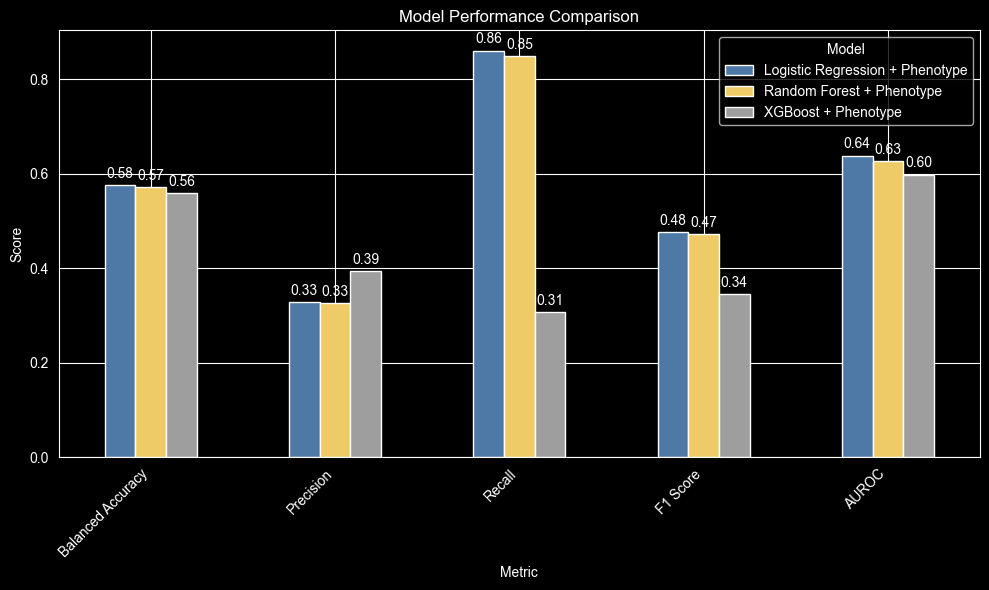

In [89]:
model_comparison(phenotype_model_comparison_df)

Comparison Table

In [90]:
baseline_results_df = model_comparison_df.copy()
baseline_results_df["Feature Set"] = "Baseline"

phenotype_results_compare_df = phenotype_model_comparison_df.copy()
phenotype_results_compare_df["Feature Set"] = "Baseline + Phenotype"

baseline_vs_phenotype_df = pd.concat(
    [
        baseline_results_df,
        phenotype_results_compare_df
    ],
    ignore_index=True
)

baseline_vs_phenotype_df = baseline_vs_phenotype_df[
    [
        "Model",
        "Feature Set",
        "Threshold",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUROC"
    ]
]

baseline_vs_phenotype_df.round(3)

,Model,Feature Set,Threshold,Balanced Accuracy,Precision,Recall,F1 Score,AUROC
0,Logistic Regression,Baseline,0.4,0.576,0.329,0.860,0.476,0.638
1,Random Forest,Baseline,0.4,0.570,0.326,0.843,0.470,0.630
2,XGBoost,Baseline,0.4,0.559,0.396,0.307,0.346,0.610
3,Logistic Regression + Phenotype,Baseline + Phenotype,0.4,0.576,0.329,0.860,0.476,0.638
4,Random Forest + Phenotype,Baseline + Phenotype,0.4,0.572,0.327,0.848,0.472,0.626
5,XGBoost + Phenotype,Baseline + Phenotype,0.4,0.558,0.394,0.307,0.345,0.598


The phenotype + SL models did not meaningfully improve performance, feature importance was not repeated as a full separate analysis. Instead, the phenotype model was checked to see whether the phenotype variable appeared among the stronger predictors. This allowed us to evaluate whether the engineered phenotype feature contributed useful signal without duplicating the full baseline feature-importance section.

In [91]:
# Assess whether or not phenotype matter in the supervised learning and phenotype model?

model = lr_phenotype_model

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": abs(coefficients)
})

importance_df["Feature"] = [
    feature.replace("num__", "").replace("cat__", "")
    for feature in importance_df["Feature"]
]

phenotype_importance_df = importance_df[
    importance_df["Feature"].str.contains("Phenotype", case=False)
].sort_values(
    by="Importance",
    ascending=True
)

phenotype_importance_df

,Feature,Importance
17,Phenotype_0,0.000000
18,Phenotype_1,0.000000
19,Phenotype_2,0.000000
20,Phenotype_3,0.006958


In [ ]:
# Plot phenotype importance

plt.figure(figsize=(7, 4))

plt.barh(
    phenotype_importance_df["Feature"],
    phenotype_importance_df["Importance"]
)


plt.title("Phenotype Importance in Logistic Regression Model")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Phenotype Feature")
plt.tight_layout()
plt.show()

The phenotype feature did not significantly improve the supervised model. Although the unsupervised clustering produced interpretable cardiometabolic groups, those group labels did not add much predictive information once the original variables such as age, BMI, waist circumference, blood pressure, inflammation markers, and activity measures were already included. This tells us that the supervised model was already capturing most of the useful signal from the individual cardiometabolic variables, so compressing those variables into phenotype labels did not strengthen prediction.